# Dataset Generation


In [1]:
import re
import json
import random
import numpy as np
from collections import Counter

DATASET_SIZE = 1
OUTPUT_FILE = "demonstrations.txt"

# Item categories
CONTAINERS = ["pot", "pan", "plate", "bowl", "glass", "measuring_cup"]
LIQUID_INGREDIENTS = ["milk", "oil"]
SOLID_INGREDIENTS  = ["tomato", "garlic", "onion", "mushroom", "lettuce",
                        "cheese", "rice", "yoghurt", "strawberries", "banana",
                        "egg", "fish", "chicken", "meat",
                        "salt", "spice1", "spice2", "mixture"]
INGREDIENTS = LIQUID_INGREDIENTS + SOLID_INGREDIENTS
ITEMS = CONTAINERS + INGREDIENTS
CUTTABLES  = ["tomato", "onion", "mushroom", "lettuce", "banana", "strawberries", "chicken", "fish", "cheese"]
GRATABLE   = ["cheese"]
COOKABLES  = ["meat", "egg", "rice", "tomato", "onion", "mushroom", "chicken", "fish", "mixture"]
SEASONINGS = ["salt", "spice1", "spice2", "garlic"]
# Locations (places, not tools)
LOCATIONS = ["storage", "prep_station", "cooking_station", "plating_station", "serving_station", "washing_station", "blending_station"]
# Tools at locations
TOOLS = {"prep_station":["cutting_board", "grater"],    "cooking_station":  ["stove"],      "washing_station":  ["sink"],       "blending_station": ["blender"]}


class StateTracker:
    def __init__(self):
        self.feature_map = {}
        idx = 0
        # 1. Item locations
        for item in ITEMS:
            for loc in LOCATIONS:
                self.feature_map[f"{item}_at_{loc}"] = idx
                idx += 1
        # 2. Containment (container_contains_ingredient)
        for container in CONTAINERS:
            for ingredient in INGREDIENTS:
                self.feature_map[f"{container}_contains_{ingredient}"] = idx
                idx += 1
        # 3. Cut status
        for item in CUTTABLES:
            self.feature_map[f"{item}_cut"] = idx
            idx += 1
        # 4. Grated status
        for item in GRATABLE:
            self.feature_map[f"{item}_grated"] = idx
            idx += 1
        # 5. Cooked status
        for item in COOKABLES:
            self.feature_map[f"{item}_cooked"] = idx
            idx += 1
        # 6. Seasoned status (any ingredient can be seasoned)
        for item in INGREDIENTS:
            self.feature_map[f"{item}_seasoned"] = idx
            idx += 1
        # 7. Washed status
        for item in ITEMS:
            self.feature_map[f"{item}_washed"] = idx
            idx += 1
        # 8. Tool states
        self.feature_map["stove_on"]   = idx; idx += 1
        self.feature_map["sink_on"]    = idx; idx += 1
        self.feature_map["blender_on"] = idx; idx += 1
        # 9. Task completion
        self.feature_map["plate_served"] = idx; idx += 1

        # 10. Mixture composition — records WHICH ingredients were combined/blended. Persists after combine()/blend(), so post-combine states of e.g. tomato+onion soup vs mushroom+onion soup remain distinguishable.
        for ingredient in INGREDIENTS:
            if ingredient != "mixture":
                self.feature_map[f"{ingredient}_in_mixture"] = idx
                idx += 1
        # 11. Seasoning identity — tracks WHICH seasoning was applied to each ingredient. Replaces the binary "seasoned" flag with per-seasoning-per-ingredient flags. This allows garlic_fish vs spiced_fish to be distinguished in feature space.
        for seasoning in SEASONINGS:
            for item in INGREDIENTS:
                self.feature_map[f"{item}_seasoned_with_{seasoning}"] = idx
                idx += 1

        self.n_features = idx
        self.reset()

    def reset(self):
        self.current_state = np.zeros(self.n_features, dtype=int)
        # Only real physical items start at storage. 'mixture' is a derived product that only exists after combine/blend — it should NOT be pre-placed.
        for item in ITEMS:
            if item != "mixture": self.set_feature(f"{item}_at_storage", 1)

    def set_feature(self, key, value):
        if key in self.feature_map: self.current_state[self.feature_map[key]] = value

    def get_feature(self, key):
        return self.current_state[self.feature_map.get(key, -1)] if key in self.feature_map else 0

    def get_state_vector(self):
        return self.current_state.copy()

    def get_item_location(self, item):
        for loc in LOCATIONS:
            if self.get_feature(f"{item}_at_{loc}") == 1: return loc
        return None

    def is_contained(self, item):
        for container in CONTAINERS:
            if self.get_feature(f"{container}_contains_{item}") == 1: return container
        return None

    def apply_action(self, action_str):
        action_str = action_str.strip()
        def _parse(s):
            content = s[s.find("(")+1:s.find(")")]
            return [p.strip() for p in content.split(",")]
        def _loc(part): 
            return part.split("=")[1] if "=" in part else part
        
        if action_str.startswith("transfer"):
            parts    = _parse(action_str)
            item     = parts[0]
            from_loc = _loc(parts[1])
            to_loc   = _loc(parts[2])
            if self.get_feature(f"{item}_at_{from_loc}") != 1:                          raise ValueError(f"Precondition failed: {item} not at {from_loc}")
            if self.is_contained(item):                                                 raise ValueError(f"Precondition failed: {item} is contained, use unload first")
            self.set_feature(f"{item}_at_{from_loc}", 0)
            self.set_feature(f"{item}_at_{to_loc}",   1)

        elif action_str.startswith("load"):
            parts     = _parse(action_str)
            item      = parts[0]
            container = parts[1]
            location  = parts[2]
            if self.get_feature(f"{item}_at_{location}") != 1:                          raise ValueError(f"Precondition failed: {item} not at {location}")
            if self.get_feature(f"{container}_at_{location}") != 1:                     raise ValueError(f"Precondition failed: {container} not at {location}")
            if self.is_contained(item):                                                 raise ValueError(f"Precondition failed: {item} already contained")
            # Clear the item's location bit — it is now inside the container, not free at the station
            self.set_feature(f"{item}_at_{location}", 0)
            self.set_feature(f"{container}_contains_{item}", 1)

        elif action_str.startswith("unload"):
            parts     = _parse(action_str)
            item      = parts[0]
            container = parts[1]
            location  = parts[2]
            if self.get_feature(f"{container}_contains_{item}") != 1:                   raise ValueError(f"Precondition failed: {item} not in {container}")
            if self.get_feature(f"{container}_at_{location}") != 1:                     raise ValueError(f"Precondition failed: {container} not at {location}")
            self.set_feature(f"{container}_contains_{item}", 0)
            # Item is now free at the container's current location
            self.set_feature(f"{item}_at_{location}", 1)

        elif action_str.startswith("move_container"):
            parts     = _parse(action_str)
            container = parts[0]
            from_loc  = _loc(parts[1])
            to_loc    = _loc(parts[2])
            if self.get_feature(f"{container}_at_{from_loc}") != 1:                     raise ValueError(f"Precondition failed: {container} not at {from_loc}")
            self.set_feature(f"{container}_at_{from_loc}", 0)
            self.set_feature(f"{container}_at_{to_loc}",   1)
            for ingredient in INGREDIENTS:
                if self.get_feature(f"{container}_contains_{ingredient}") == 1:
                    self.set_feature(f"{ingredient}_at_{from_loc}", 0)
                    self.set_feature(f"{ingredient}_at_{to_loc}",   1)

        elif action_str.startswith("cut"):
            parts    = _parse(action_str)
            item     = parts[0]
            location = parts[1] if len(parts) > 1 else "prep_station"
            if item not in CUTTABLES:                                                   raise ValueError(f"Precondition failed: {item} is not cuttable")
            if self.get_feature(f"{item}_at_{location}") != 1:                          raise ValueError(f"Precondition failed: {item} not at {location}")
            self.set_feature(f"{item}_cut", 1)

        elif action_str.startswith("grate"):
            parts    = _parse(action_str)
            item     = parts[0]
            location = parts[1] if len(parts) > 1 else "prep_station"
            if item not in GRATABLE:                                                    raise ValueError(f"Precondition failed: {item} is not gratable")
            if self.get_feature(f"{item}_at_{location}") != 1:                          raise ValueError(f"Precondition failed: {item} not at {location}")
            self.set_feature(f"{item}_grated", 1)

        elif action_str.startswith("cook ") or action_str.startswith("cook("):
            parts     = _parse(action_str)
            item      = parts[0]
            container = parts[1] if len(parts) > 1 else "pot"
            location  = parts[2] if len(parts) > 2 else "cooking_station"
            if item not in COOKABLES:                                                   raise ValueError(f"Precondition failed: {item} is not cookable")
            if self.get_feature(f"{container}_contains_{item}") != 1:                   raise ValueError(f"Precondition failed: {item} not in {container}")
            if self.get_feature(f"{container}_at_{location}") != 1:                     raise ValueError(f"Precondition failed: {container} not at {location}")
            if location == "cooking_station" and self.get_feature("stove_on") != 1:     raise ValueError("Precondition failed: stove not on")
            self.set_feature(f"{item}_cooked", 1)

        elif action_str.startswith("cook_contents"):
            parts     = _parse(action_str)
            container = parts[0]
            location  = parts[1] if len(parts) > 1 else "cooking_station"
            if self.get_feature(f"{container}_at_{location}") != 1:                     raise ValueError(f"Precondition failed: {container} not at {location}")
            if location == "cooking_station" and self.get_feature("stove_on") != 1:     raise ValueError("Precondition failed: stove not on")
            for ingredient in INGREDIENTS:
                if self.get_feature(f"{container}_contains_{ingredient}") == 1:
                    if ingredient in COOKABLES: self.set_feature(f"{ingredient}_cooked", 1)

        elif action_str.startswith("combine"):
            parts     = _parse(action_str)
            container = parts[0]
            location  = parts[1] if len(parts) > 1 else None
            if location and self.get_feature(f"{container}_at_{location}") != 1:        raise ValueError(f"Precondition failed: {container} not at {location}")
            contained = [ing for ing in INGREDIENTS if ing != "mixture" and self.get_feature(f"{container}_contains_{ing}") == 1]
            if len(contained) < 2:                                                      raise ValueError(f"Precondition failed: combine requires >=2 ingredients in {container}, found {contained}")
            for ing in contained:
                self.set_feature(f"{container}_contains_{ing}", 0)
                self.set_feature(f"{ing}_in_mixture", 1)   # record composition; persists post-combine
            self.set_feature(f"{container}_contains_mixture", 1)
            if location: self.set_feature(f"mixture_at_{location}", 1)

        elif action_str.startswith("season_container"):
            parts     = _parse(action_str)
            container = parts[0]
            seasoning = parts[1]
            location  = parts[2] if len(parts) > 2 else None
            if seasoning not in SEASONINGS:                                             raise ValueError(f"Precondition failed: {seasoning} is not a seasoning")
            if location and self.get_feature(f"{container}_at_{location}") != 1:        raise ValueError(f"Precondition failed: {container} not at {location}")
            for ing in INGREDIENTS:
                if self.get_feature(f"{container}_contains_{ing}") == 1:
                    self.set_feature(f"{ing}_seasoned", 1)
                    self.set_feature(f"{ing}_seasoned_with_{seasoning}", 1)

        elif action_str.startswith("season"):
            parts     = _parse(action_str)
            target    = parts[0]
            seasoning = parts[1]
            location  = parts[2] if len(parts) > 2 else None
            if seasoning not in SEASONINGS:                                             raise ValueError(f"Precondition failed: {seasoning} is not a seasoning")
            if location and self.get_feature(f"{target}_at_{location}") != 1:           raise ValueError(f"Precondition failed: {target} not at {location}")
            self.set_feature(f"{target}_seasoned", 1)                                  # keep backward-compat binary flag
            self.set_feature(f"{target}_seasoned_with_{seasoning}", 1) 

        elif action_str.startswith("pour"):
            parts          = _parse(action_str)
            liquid         = parts[0]
            from_container = parts[1]
            to_container   = parts[2]
            location       = parts[3] if len(parts) > 3 else None
            if liquid not in LIQUID_INGREDIENTS:                                        raise ValueError(f"Precondition failed: {liquid} is not a liquid")
            if self.get_feature(f"{from_container}_contains_{liquid}") != 1:            raise ValueError(f"Precondition failed: {liquid} not in {from_container}")
            if location:
                if self.get_feature(f"{from_container}_at_{location}") != 1:            raise ValueError(f"Precondition failed: {from_container} not at {location}")
                if self.get_feature(f"{to_container}_at_{location}") != 1:              raise ValueError(f"Precondition failed: {to_container} not at {location}")
            self.set_feature(f"{from_container}_contains_{liquid}", 0)
            self.set_feature(f"{to_container}_contains_{liquid}",   1)
            if location: self.set_feature(f"{liquid}_at_{location}", 1)

        elif action_str.startswith("turn_on"):
            parts = _parse(action_str)
            tool  = parts[0]
            if   tool == "stove":   self.set_feature("stove_on",   1)
            elif tool == "sink":    self.set_feature("sink_on",    1)
            elif tool == "blender": self.set_feature("blender_on", 1)

        elif action_str.startswith("turn_off"):
            parts = _parse(action_str)
            tool  = parts[0]
            if   tool == "stove":   self.set_feature("stove_on",   0)
            elif tool == "sink":    self.set_feature("sink_on",    0)
            elif tool == "blender": self.set_feature("blender_on", 0)

        elif action_str.startswith("blend"):
            parts     = _parse(action_str)
            container = parts[0]
            location  = parts[1] if len(parts) > 1 else "blending_station"
            if self.get_feature(f"{container}_at_{location}") != 1:                     raise ValueError(f"Precondition failed: {container} not at {location}")
            if self.get_feature("blender_on") != 1:                                     raise ValueError("Precondition failed: blender not on")
            contained = [ing for ing in INGREDIENTS if ing != "mixture" and self.get_feature(f"{container}_contains_{ing}") == 1]
            if len(contained) < 1:                                                      raise ValueError(f"Precondition failed: blend requires >=1 ingredient in {container}")
            for ing in contained:
                self.set_feature(f"{container}_contains_{ing}", 0)
                self.set_feature(f"{ing}_in_mixture", 1)   # record blend composition
            self.set_feature(f"{container}_contains_mixture", 1)
            self.set_feature(f"mixture_at_{location}", 1)

        elif action_str.startswith("serve"):
            parts    = _parse(action_str)
            plate    = parts[0]
            location = parts[1] if len(parts) > 1 else "serving_station"
            if self.get_feature(f"{plate}_at_{location}") != 1:                         raise ValueError(f"Precondition failed: {plate} not at {location}")
            self.set_feature("plate_served", 1)

        elif action_str.startswith("wash"):
            parts    = _parse(action_str)
            item     = parts[0]
            location = parts[1] if len(parts) > 1 else "washing_station"
            if self.get_feature(f"{item}_at_{location}") != 1:                          raise ValueError(f"Precondition failed: {item} not at {location}")
            self.set_feature(f"{item}_washed", 1)

        else:                                                                           raise ValueError(f"Unknown action: {action_str}")

class RecipeGenerator:
    def __init__(self):
        self.demos   = []
        self.tracker = StateTracker()

    def _record_trajectory(self, actions):
        self.tracker.reset()
        trajectory = []
        for action in actions:
            state_vector = self.tracker.get_state_vector().tolist()
            trajectory.append({"state": state_vector, "action": action})
            try:
                self.tracker.apply_action(action)
            except ValueError as e:
                print(f"ERROR applying action '{action}': {e}")
                raise
        final_state_vector = self.tracker.get_state_vector().tolist()
        trajectory.append({"state": final_state_vector, "action": "stop"})
        self.demos.append(trajectory)



    def generate_grilled_steak(self): return [
            "transfer (pan, from=storage, to=cooking_station)",
            "load (meat, bowl, storage)",
            "move_container (bowl, from=storage, to=cooking_station)",
            "unload (meat, bowl, cooking_station)",
            "load (meat, pan, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pan, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",  # LATE
            "unload (meat, pan, cooking_station)",
            "load (meat, bowl, cooking_station)",
            "move_container (bowl, from=cooking_station, to=plating_station)",
            "unload (meat, bowl, plating_station)",
            "load (meat, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "transfer (pan, from=cooking_station, to=washing_station)",
            "wash (pan, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    def generate_boiled_eggs(self): return [
            "transfer (pot, from=storage, to=cooking_station)",
            "load (egg, bowl, storage)",
            "move_container (bowl, from=storage, to=cooking_station)",
            "unload (egg, bowl, cooking_station)",
            "load (egg, pot, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pot, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (pot, from=cooking_station, to=plating_station)",
            "unload (egg, pot, plating_station)",
            "load (egg, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "transfer (pot, from=plating_station, to=washing_station)",
            "wash (pot, washing_station)",
            "transfer (bowl, from=cooking_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    def generate_boiled_rice(self): return [
        "transfer (pot, from=storage, to=cooking_station)",
        "load (rice, bowl, storage)",
        "move_container (bowl, from=storage, to=cooking_station)",
        "unload (rice, bowl, cooking_station)",
        "turn_on (stove, cooking_station)",
        "load (rice, pot, cooking_station)",             # LATE: after stove-on (default)
        "cook_contents (pot, cooking_station)",
        "turn_off (stove, cooking_station)",
        "transfer (plate, from=storage, to=plating_station)",   # LATE plate
        "unload (rice, pot, cooking_station)",
        "load (rice, bowl, cooking_station)",
        "move_container (bowl, from=cooking_station, to=plating_station)",
        "unload (rice, bowl, plating_station)",
        "load (rice, plate, plating_station)",
        "move_container (plate, from=plating_station, to=serving_station)",
        "serve (plate, serving_station)",
        "transfer (pot, from=cooking_station, to=washing_station)",
        "wash (pot, washing_station)",
        "transfer (bowl, from=plating_station, to=washing_station)",
        "wash (bowl, washing_station)"]
    def generate_simple_salad(self): return [
            # Cuts happen LATE (just before loads) — chopping=True moves them early
            # Plate arrives LATE
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (lettuce, from=storage, to=prep_station)",
            "transfer (onion, from=storage, to=prep_station)",
            "cut (lettuce, prep_station)",                           # cut immediately before load
            "load (lettuce, bowl, prep_station)",
            "cut (onion, prep_station)",                             # cut immediately before load
            "load (onion, bowl, prep_station)",
            "combine (bowl, prep_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (bowl, from=prep_station, to=plating_station)",
            "unload (mixture, bowl, plating_station)",
            "load (mixture, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "move_container (plate, from=serving_station, to=washing_station)",
            "wash (plate, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    def generate_burger(self): return [
            # Plate arrives LATE; lettuce is retrieved LATE (just before cut)
            # → taking_meat_from_dispenser & delivering_dishes have clear toggle effect
            "transfer (pan, from=storage, to=cooking_station)",
            "load (meat, bowl, storage)",
            "move_container (bowl, from=storage, to=cooking_station)",
            "unload (meat, bowl, cooking_station)",
            "load (meat, pan, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pan, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "unload (meat, pan, cooking_station)",
            "load (meat, bowl, cooking_station)",
            "move_container (bowl, from=cooking_station, to=plating_station)",
            "unload (meat, bowl, plating_station)",
            "load (meat, plate, plating_station)",
            "transfer (lettuce, from=storage, to=prep_station)",    # LATE lettuce retrieval
            "move_container (bowl, from=plating_station, to=prep_station)",
            "cut (lettuce, prep_station)",
            "load (lettuce, bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=plating_station)",
            "unload (lettuce, bowl, plating_station)",
            "load (lettuce, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "transfer (pan, from=cooking_station, to=washing_station)",
            "wash (pan, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    
    def generate_tomato_soup(self): return [
            # Tomato retrieved LATE (just before cut); plate LATE
            "transfer (pot, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "turn_on (stove, cooking_station)",
            "transfer (tomato, from=storage, to=prep_station)",     # LATE tomato retrieval
            "cut (tomato, prep_station)",
            "load (tomato, bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (tomato, bowl, cooking_station)",
            "load (tomato, pot, cooking_station)",
            "cook_contents (pot, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "unload (tomato, pot, cooking_station)",
            "load (tomato, bowl, cooking_station)",
            "move_container (bowl, from=cooking_station, to=plating_station)",
            "unload (tomato, bowl, plating_station)",
            "load (tomato, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "transfer (pot, from=cooking_station, to=washing_station)",
            "wash (pot, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    def generate_tomato_onion_soup_v1(self): return [
            # Both ingredients retrieved LATE; cuts just-in-time; plate LATE
            # → chopping=True, delivering=True, taking_*=True all have clear effect
            "transfer (pot, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (tomato, from=storage, to=prep_station)",     # tomato retrieved late
            "cut (tomato, prep_station)",
            "load (tomato, bowl, prep_station)",
            "transfer (onion, from=storage, to=prep_station)",      # onion retrieved late
            "cut (onion, prep_station)",
            "load (onion, bowl, prep_station)",
            "combine (bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (mixture, bowl, cooking_station)",
            "load (mixture, pot, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pot, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (pot, from=cooking_station, to=plating_station)",
            "unload (mixture, pot, plating_station)",
            "load (mixture, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "move_container (pot, from=plating_station, to=washing_station)",
            "wash (pot, washing_station)",
            "transfer (bowl, from=cooking_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    def generate_tomato_onion_soup_v2(self): return [
            # Same as v1 but onion prepped first
            "transfer (pot, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (onion, from=storage, to=prep_station)",
            "cut (onion, prep_station)",
            "load (onion, bowl, prep_station)",
            "transfer (tomato, from=storage, to=prep_station)",
            "cut (tomato, prep_station)",
            "load (tomato, bowl, prep_station)",
            "combine (bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (mixture, bowl, cooking_station)",
            "load (mixture, pot, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pot, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (pot, from=cooking_station, to=plating_station)",
            "unload (mixture, pot, plating_station)",
            "load (mixture, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "move_container (pot, from=plating_station, to=washing_station)",
            "wash (pot, washing_station)",
            "transfer (bowl, from=cooking_station, to=washing_station)",
            "wash (bowl, washing_station)"]
    def generate_mushroom_soup(self): return [
            "transfer (pot, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (mushroom, from=storage, to=prep_station)",
            "cut (mushroom, prep_station)",
            "load (mushroom, bowl, prep_station)",
            "transfer (onion, from=storage, to=prep_station)",
            "cut (onion, prep_station)",
            "load (onion, bowl, prep_station)",
            "combine (bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (mixture, bowl, cooking_station)",
            "load (mixture, pot, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pot, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (pot, from=cooking_station, to=plating_station)",
            "unload (mixture, pot, plating_station)",
            "load (mixture, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "move_container (pot, from=plating_station, to=washing_station)",
            "wash (pot, washing_station)",
            "transfer (bowl, from=cooking_station, to=washing_station)",
            "wash (bowl, washing_station)"]

    # new recipes
    def generate_seasoned_chicken(self):
        return [
            "transfer (pan, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (chicken, from=storage, to=prep_station)",
            "season (chicken, salt, prep_station)",
            "season (chicken, spice1, prep_station)",
            "load (chicken, bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (chicken, bowl, cooking_station)",
            "load (chicken, pan, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pan, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "unload (chicken, pan, cooking_station)",
            "load (chicken, bowl, cooking_station)",
            "move_container (bowl, from=cooking_station, to=plating_station)",
            "unload (chicken, bowl, plating_station)",
            "load (chicken, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "transfer (pan, from=cooking_station, to=washing_station)",
            "wash (pan, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)",
        ]
    def generate_garlic_fish(self):
        return [
            "transfer (pan, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (fish, from=storage, to=prep_station)",
            "season (fish, garlic, prep_station)",
            "season (fish, spice2, prep_station)",
            "load (fish, bowl, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (fish, bowl, cooking_station)",
            "load (fish, pan, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pan, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "unload (fish, pan, cooking_station)",
            "load (fish, bowl, cooking_station)",
            "move_container (bowl, from=cooking_station, to=plating_station)",
            "unload (fish, bowl, plating_station)",
            "load (fish, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "transfer (pan, from=cooking_station, to=washing_station)",
            "wash (pan, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)",
        ]
    def generate_seasoned_mixture_soup(self):
        return [
            "transfer (pot, from=storage, to=cooking_station)",
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (tomato, from=storage, to=prep_station)",
            "cut (tomato, prep_station)",
            "load (tomato, bowl, prep_station)",
            "transfer (onion, from=storage, to=prep_station)",
            "cut (onion, prep_station)",
            "load (onion, bowl, prep_station)",
            "combine (bowl, prep_station)",
            "season_container (bowl, salt, prep_station)",
            "season_container (bowl, spice1, prep_station)",
            "move_container (bowl, from=prep_station, to=cooking_station)",
            "unload (mixture, bowl, cooking_station)",
            "load (mixture, pot, cooking_station)",
            "turn_on (stove, cooking_station)",
            "cook_contents (pot, cooking_station)",
            "turn_off (stove, cooking_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (pot, from=cooking_station, to=plating_station)",
            "unload (mixture, pot, plating_station)",
            "load (mixture, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "move_container (pot, from=plating_station, to=washing_station)",
            "wash (pot, washing_station)",
            "transfer (bowl, from=cooking_station, to=washing_station)",
            "wash (bowl, washing_station)",
        ]
    def generate_grated_cheese_salad(self):
        return [
            "transfer (bowl, from=storage, to=prep_station)",
            "transfer (lettuce, from=storage, to=prep_station)",
            "transfer (cheese, from=storage, to=prep_station)",
            "cut (lettuce, prep_station)",
            "load (lettuce, bowl, prep_station)",
            "grate (cheese, prep_station)",
            "load (cheese, bowl, prep_station)",
            "combine (bowl, prep_station)",
            "transfer (plate, from=storage, to=plating_station)",   # LATE plate
            "move_container (bowl, from=prep_station, to=plating_station)",
            "unload (mixture, bowl, plating_station)",
            "load (mixture, plate, plating_station)",
            "move_container (plate, from=plating_station, to=serving_station)",
            "serve (plate, serving_station)",
            "move_container (plate, from=serving_station, to=washing_station)",
            "wash (plate, washing_station)",
            "transfer (bowl, from=plating_station, to=washing_station)",
            "wash (bowl, washing_station)",
        ]
    def generate_smoothie(self):
        return [
            "transfer (glass, from=storage, to=blending_station)",
            "transfer (measuring_cup, from=storage, to=blending_station)",
            "transfer (banana, from=storage, to=prep_station)",
            "transfer (strawberries, from=storage, to=prep_station)",
            "cut (banana, prep_station)",                           # cut late (just before load)
            "transfer (banana, from=prep_station, to=blending_station)",
            "cut (strawberries, prep_station)",                     # cut late
            "transfer (strawberries, from=prep_station, to=blending_station)",
            "transfer (milk, from=storage, to=blending_station)",
            "load (milk, measuring_cup, blending_station)",
            "pour (milk, measuring_cup, glass, blending_station)",
            "load (banana, glass, blending_station)",
            "load (strawberries, glass, blending_station)",
            "turn_on (blender, blending_station)",
            "blend (glass, blending_station)",
            "turn_off (blender, blending_station)",
            "transfer (glass, from=blending_station, to=serving_station)",
            "serve (glass, serving_station)",
            "transfer (measuring_cup, from=blending_station, to=washing_station)",
            "wash (measuring_cup, washing_station)",
        ]
    def generate_yoghurt_smoothie(self):
        return [
            "transfer (glass, from=storage, to=blending_station)",
            "transfer (measuring_cup, from=storage, to=blending_station)",
            "transfer (banana, from=storage, to=prep_station)",
            "transfer (yoghurt, from=storage, to=blending_station)",
            "cut (banana, prep_station)",                           # cut late (just before load)
            "transfer (banana, from=prep_station, to=blending_station)",
            "load (yoghurt, glass, blending_station)",
            "transfer (milk, from=storage, to=blending_station)",
            "load (milk, measuring_cup, blending_station)",
            "pour (milk, measuring_cup, glass, blending_station)",
            "load (banana, glass, blending_station)",
            "turn_on (blender, blending_station)",
            "blend (glass, blending_station)",
            "turn_off (blender, blending_station)",
            "transfer (glass, from=blending_station, to=serving_station)",
            "serve (glass, serving_station)",
            "transfer (measuring_cup, from=blending_station, to=washing_station)",
            "wash (measuring_cup, washing_station)",
        ]

    def generate_random_dataset(self, count):
        available_recipes = [self.generate_tomato_onion_soup_v1]
        print(f"Generating {count} PDDL-style demonstrations...")
        for i in range(count):
            recipe_func = random.choice(available_recipes)
            actions = recipe_func()
            self._record_trajectory(actions)
    def save_to_file(self):
        with open(OUTPUT_FILE, "w") as f:
            for demo in self.demos: f.write(json.dumps(demo) + "\n")
        print(f"Saved {len(self.demos)} trajectories to {OUTPUT_FILE}")
        print(f"State Vector Size: {self.tracker.n_features}")


# IRL

In [2]:
def load_demonstrations(filepath):
    """Load demonstrations from JSON file"""
    with open(filepath, 'r') as f: demo_lists = [json.loads(line) for line in f.read().strip().split('\n')]
    
    demonstrations = []
    all_actions = set()
    
    for demo in demo_lists:
        trajectory = [(tuple(step['state']), step['action']) for step in demo]
        demonstrations.append(trajectory)
        all_actions.update(step['action'] for step in demo)
    return demonstrations, sorted(list(all_actions))

def create_state_action_mappings(demonstrations, unique_actions):
    """Create bidirectional mappings between states/actions and indices"""
    unique_states = set()
    for trajectory in demonstrations: unique_states.update(state for state, _ in trajectory)
    
    state_to_idx    = {state: idx for idx, state in enumerate(sorted(unique_states))}
    idx_to_state    = {idx: state for state, idx in state_to_idx.items()}
    action_to_idx   = {action: idx for idx, action in enumerate(unique_actions)}
    idx_to_action   = {idx: action for action, idx in action_to_idx.items()}
    return state_to_idx, idx_to_state, action_to_idx, idx_to_action

def create_enhanced_feature_matrix(idx_to_state, col_min_known=None, col_max_known=None):
    """
    Create task-discriminative features for the expanded PDDL-style kitchen environment.
    If col_min_known / col_max_known are provided (from a previous call on the training set), use those bounds for normalisation so test states land in the same feature space. Returns (feature_matrix, col_min, col_max).
    """
    # --- dimension constants (must match StateTracker) ---
    n_items       = len(ITEMS)        # 26
    n_locations   = len(LOCATIONS)    # 7
    n_containers  = len(CONTAINERS)   # 6
    n_ingredients = len(INGREDIENTS)  # 20

    # --- section offsets ---
    LOCATION_OFFSET    = 0
    CONTAINMENT_OFFSET = n_items * n_locations                              # 182
    CUT_OFFSET         = CONTAINMENT_OFFSET + n_containers * n_ingredients  # 302
    GRATED_OFFSET      = CUT_OFFSET  + len(CUTTABLES)                       # 311
    COOKED_OFFSET      = GRATED_OFFSET + len(GRATABLE)                      # 312
    SEASONED_OFFSET    = COOKED_OFFSET + len(COOKABLES)                     # 321
    WASHED_OFFSET      = SEASONED_OFFSET + n_ingredients                    # 341
    STOVE_IDX          = WASHED_OFFSET + n_items                            # 367
    SINK_IDX           = STOVE_IDX  + 1                                     # 368
    BLENDER_IDX        = SINK_IDX   + 1                                     # 369
    SERVED_IDX         = BLENDER_IDX + 1                                    # 370

    # --- item / container / location indices ---
    pot_idx    = CONTAINERS.index("pot")
    pan_idx    = CONTAINERS.index("pan")
    plate_idx  = CONTAINERS.index("plate")
    bowl_idx   = CONTAINERS.index("bowl")
    glass_idx  = CONTAINERS.index("glass")
    mc_idx     = CONTAINERS.index("measuring_cup")

    prep_idx   = LOCATIONS.index("prep_station")
    cook_idx   = LOCATIONS.index("cooking_station")
    plat_idx   = LOCATIONS.index("plating_station")
    serve_idx  = LOCATIONS.index("serving_station")
    wash_idx   = LOCATIONS.index("washing_station")
    blend_idx  = LOCATIONS.index("blending_station")

    def iloc(item_i, loc_j): return LOCATION_OFFSET + item_i * n_locations + loc_j
    def cfeat(cont_i, ing_j): return CONTAINMENT_OFFSET + cont_i * n_ingredients + ing_j
    item_idx = {item: i for i, item in enumerate(ITEMS)}

    features = []

    for idx in range(len(idx_to_state)):
        state = np.array(idx_to_state[idx])
        feat  = []

        # === Location-based features (7 features) ===
        for loc_j in range(n_locations):
            indices = [iloc(i, loc_j) for i in range(n_items)]
            feat.append(np.sum(state[indices]))

        # === Container-specific location features (19 features) ===
        feat.append(state[iloc(pot_idx,   cook_idx)])
        feat.append(state[iloc(pan_idx,   cook_idx)])
        feat.append(state[iloc(plate_idx, plat_idx)])
        feat.append(state[iloc(plate_idx, serve_idx)])
        feat.append(state[iloc(plate_idx, wash_idx)])
        feat.append(state[iloc(bowl_idx,  prep_idx)])
        feat.append(state[iloc(bowl_idx,  cook_idx)])
        feat.append(state[iloc(bowl_idx,  plat_idx)])
        feat.append(state[iloc(glass_idx, blend_idx)])
        feat.append(state[iloc(mc_idx,    blend_idx)])
        feat.append(state[iloc(glass_idx, serve_idx)])
        feat.append(state[iloc(pot_idx,  wash_idx)])
        feat.append(state[iloc(pan_idx,  wash_idx)])
        feat.append(state[iloc(bowl_idx, wash_idx)])
        feat.append(state[iloc(glass_idx, wash_idx)])
        feat.append(state[iloc(mc_idx,   wash_idx)])
        cooking_vessel_at_cook = (state[iloc(pot_idx, cook_idx)] + state[iloc(pan_idx, cook_idx)])
        feat.append(cooking_vessel_at_cook)
        items_at_prep = np.sum([state[iloc(i, prep_idx)] for i in range(n_items)])
        feat.append(items_at_prep)
        items_at_blend = np.sum([state[iloc(i, blend_idx)] for i in range(n_items)])
        feat.append(items_at_blend)

        # === Containment features (8 features) ===
        total_contained = np.sum(state[CONTAINMENT_OFFSET:CONTAINMENT_OFFSET + n_containers * n_ingredients])
        feat.append(total_contained)
        items_in_pot  = np.sum(state[cfeat(pot_idx,  0):cfeat(pot_idx,  0) + n_ingredients])
        items_in_pan  = np.sum(state[cfeat(pan_idx,  0):cfeat(pan_idx,  0) + n_ingredients])
        items_in_plate= np.sum(state[cfeat(plate_idx,0):cfeat(plate_idx,0) + n_ingredients])
        items_in_bowl = np.sum(state[cfeat(bowl_idx, 0):cfeat(bowl_idx, 0) + n_ingredients])
        items_in_glass= np.sum(state[cfeat(glass_idx,0):cfeat(glass_idx,0) + n_ingredients])
        items_in_mc   = np.sum(state[cfeat(mc_idx,   0):cfeat(mc_idx,   0) + n_ingredients])
        feat.append(items_in_pot)
        feat.append(items_in_pan)
        feat.append(items_in_plate)
        feat.append(items_in_bowl)
        feat.append(items_in_glass)
        feat.append(items_in_mc)
        mixture_idx = INGREDIENTS.index("mixture")
        mixture_anywhere = np.sum([state[cfeat(c, mixture_idx)] for c in range(n_containers)])
        feat.append(mixture_anywhere)

        # === Processing state features ===
        feat.extend(state[CUT_OFFSET:CUT_OFFSET + len(CUTTABLES)])
        total_cut = np.sum(state[CUT_OFFSET:CUT_OFFSET + len(CUTTABLES)])
        feat.append(total_cut)
        total_grated = np.sum(state[GRATED_OFFSET:GRATED_OFFSET + len(GRATABLE)])
        feat.append(total_grated)
        feat.extend(state[COOKED_OFFSET:COOKED_OFFSET + len(COOKABLES)])
        total_cooked = np.sum(state[COOKED_OFFSET:COOKED_OFFSET + len(COOKABLES)])
        feat.append(total_cooked)
        total_seasoned = np.sum(state[SEASONED_OFFSET:SEASONED_OFFSET + n_ingredients])
        feat.append(total_seasoned)
        for ing_name in ["chicken", "fish", "mixture"]:
            ing_j = INGREDIENTS.index(ing_name)
            feat.append(state[SEASONED_OFFSET + ing_j])
        total_washed = np.sum(state[WASHED_OFFSET:WASHED_OFFSET + n_items])
        feat.append(total_washed)

        # === Tool usage features (6 features) ===
        stove_on   = state[STOVE_IDX]
        sink_on    = state[SINK_IDX]
        blender_on = state[BLENDER_IDX]
        feat.append(stove_on)
        feat.append(stove_on * cooking_vessel_at_cook)
        feat.append(stove_on * total_contained)
        feat.append(sink_on)
        feat.append(blender_on)
        feat.append(blender_on * items_in_glass)

        # === Workflow progress features (9 features) ===
        served = state[SERVED_IDX]
        feat.append(int(total_cut > 0))
        feat.append(int(total_cooked > 0))
        feat.append(int(items_in_plate > 0))
        feat.append(int(items_in_glass > 0))
        feat.append(served)
        feat.append(int(total_washed > 0))
        feat.append(int(total_grated > 0))
        feat.append(int(total_seasoned > 0))
        workflow_complete_cooking = int(total_cut > 0) * int(total_cooked > 0) * int(served) * int(total_washed > 0)
        feat.append(workflow_complete_cooking)
        workflow_complete_nocook = int(total_cut > 0) * int(served) * int(total_washed > 0) * int(total_cooked == 0)
        feat.append(workflow_complete_nocook)
        workflow_complete_general = int(served) * int(total_washed > 0)
        feat.append(workflow_complete_general)

        # === Ingredient-specific location features ===
        KEY_INGREDIENTS_DISC = [
            "tomato", "onion", "mushroom", "rice", "meat",
            "chicken", "fish", "egg", "banana", "strawberries",
            "lettuce", "cheese",
            "garlic",
            "yoghurt",
            "milk",
        ]
        KEY_LOC_INDICES = [prep_idx, cook_idx, plat_idx, blend_idx]
        for ing_name in KEY_INGREDIENTS_DISC:
            if ing_name in ITEMS:
                ing_item_i = item_idx[ing_name]
                for loc_j in KEY_LOC_INDICES:
                    feat.append(state[iloc(ing_item_i, loc_j)])

        # === Ingredient-in-container discriminative features ===
        KEY_CONT_INDICES = [pot_idx, pan_idx, plate_idx, bowl_idx]
        for ing_name in KEY_INGREDIENTS_DISC:
            if ing_name in INGREDIENTS:
                ing_j = INGREDIENTS.index(ing_name)
                for cont_i in KEY_CONT_INDICES:
                    feat.append(state[cfeat(cont_i, ing_j)])

        # === Individual ingredient seasoning flags ===
        for ing_name in KEY_INGREDIENTS_DISC:
            if ing_name in INGREDIENTS:
                ing_j = INGREDIENTS.index(ing_name)
                feat.append(state[SEASONED_OFFSET + ing_j])

        # === Mixture composition features ===
        IN_MIXTURE_OFFSET = SERVED_IDX + 1  # 371
        for ing_name in KEY_INGREDIENTS_DISC:
            if ing_name in INGREDIENTS and ing_name != "mixture":
                ing_j = INGREDIENTS.index(ing_name)
                feat.append(state[IN_MIXTURE_OFFSET + ing_j])

        # === Seasoning identity features (section 11) ===
        SEASONING_IDENTITY_OFFSET = IN_MIXTURE_OFFSET + (len(INGREDIENTS) - 1)  # 390
        for s_i, seasoning in enumerate(SEASONINGS):
            for ing_name in KEY_INGREDIENTS_DISC:
                if ing_name in INGREDIENTS:
                    ing_j = INGREDIENTS.index(ing_name)
                    feat.append(state[SEASONING_IDENTITY_OFFSET + s_i * len(INGREDIENTS) + ing_j])

        features.append(feat)

    feature_matrix = np.array(features, dtype=float)

    if col_min_known is not None and col_max_known is not None:
        col_min   = col_min_known
        col_max   = col_max_known
    else:
        col_min = feature_matrix.min(axis=0)
        col_max = feature_matrix.max(axis=0)

    col_range = col_max - col_min
    col_range[col_range == 0] = 1.0
    feature_matrix = (feature_matrix - col_min) / col_range
    feature_matrix = np.clip(feature_matrix, 0.0, 1.0)

    return feature_matrix, col_min, col_max

def max_ent_irl(demonstrations, feature_matrix, state_to_idx, action_to_idx, n_iterations=100, learning_rate=0.05, temperature=0.5, gamma=0.9, init_weights=None, demo_weights=None):
    """
    Maximum Entropy IRL with optional per-demonstration importance weights.
    demo_weights :  array-like of shape (len(demonstrations),) or None. Each entry is the importance weight of the corresponding demonstration.
                    Weights affect both the empirical feature-expectation computation and the starting-state distribution used for Monte-Carlo rollouts. If None, all demonstrations are treated as equally important (uniform weights).
    """
    n_states, n_features  = feature_matrix.shape[0], feature_matrix.shape[1]
    n_actions, MC_Count, verbose  = len(action_to_idx), 500, True

    # Normalise demo weights
    if demo_weights is None:
        w = np.ones(len(demonstrations), dtype=float)
    else:
        w = np.array(demo_weights, dtype=float)
    w_sum = w.sum()
    if w_sum == 0:
        w       = np.ones(len(demonstrations), dtype=float)
        w_sum   = float(len(demonstrations))
    demo_probs  = w / w_sum   # probability distribution over demos (used for MC sampling)

    if verbose:                                                                                                     print(f"\nStarting MaxEnt IRL,     States: {n_states}, Actions: {n_actions}, Features: {n_features}")
    if verbose and demo_weights is not None:                                                                        print(f"  Demo weights: [{', '.join(f'{wi:.2f}' for wi in w)}]  (sum={w_sum:.2f})")
    if init_weights is not None and len(init_weights) == n_features:    reward_weights = init_weights.copy();       print(f"  Warm-starting from previous weights (norm={np.linalg.norm(init_weights):.3f})")
    else:                                                               reward_weights = np.random.randn(n_features) * 0.1

    # Weighted empirical feature expectations
    empirical_feature_expectations = np.zeros(n_features)
    state_action_pairs = set()
    transition_model   = {}

    for i, trajectory in enumerate(demonstrations):
        traj_features = np.zeros(n_features)
        for t, (state, action) in enumerate(trajectory):
            s_idx           = state_to_idx[state]
            traj_features   += (gamma ** t) * feature_matrix[s_idx]
        empirical_feature_expectations  += w[i] * traj_features
    empirical_feature_expectations      /= w_sum

    for trajectory in demonstrations:
        for i in range(len(trajectory)):
            state, action = trajectory[i]
            s_idx, a_idx  = state_to_idx[state], action_to_idx[action]
            state_action_pairs.add((s_idx, a_idx))
            if i < len(trajectory) - 1: transition_model[(s_idx, a_idx)] = state_to_idx[trajectory[i + 1][0]]

    if verbose:                                                                                                     print(f"Found {len(state_action_pairs)} unique (state, action) pairs,     Empirical feature expectation norm: {np.linalg.norm(empirical_feature_expectations):.4f}")

    best_diff       = float('inf')
    patience        = 0
    no_improve_count = 0
    best_weights    = reward_weights.copy()
    momentum        = np.zeros(n_features)
    momentum_beta   = 0.9
    LR_DECAY_EVERY  = 20

    rewards  = feature_matrix @ reward_weights
    values   = rewards.copy()
    q_values = {}
    for iteration in range(n_iterations):
        current_lr = learning_rate * (0.97 ** (no_improve_count // LR_DECAY_EVERY))
        rewards    = feature_matrix @ reward_weights

        # Soft Bellman value iteration
        max_vi_iters = 50
        for vi_iter in range(max_vi_iters):
            new_values = rewards.copy()
            for (s_idx, a_idx) in state_action_pairs:
                ns                          = transition_model.get((s_idx, a_idx))
                q_values[(s_idx, a_idx)]    = rewards[s_idx] + (gamma * values[ns] if ns is not None else 0.0)
            for s_idx in range(n_states):
                avail_qs = [q_values[(s_idx, a_idx)] for a_idx in range(n_actions) if (s_idx, a_idx) in q_values]
                if avail_qs:
                    avail_qs            = np.array(avail_qs)
                    max_q               = np.max(avail_qs)
                    new_values[s_idx]   = max_q + temperature * np.log(np.sum(np.exp((avail_qs - max_q) / temperature)))
            delta  = np.max(np.abs(new_values - values))
            values = new_values
            if delta < 1e-6: break

        policy = {}
        for s_idx in range(n_states):
            state_qs = [(a_idx, q_values[(s_idx, a_idx)]) for a_idx in range(n_actions) if (s_idx, a_idx) in q_values]
            if state_qs:
                state_actions, state_q_vals = zip(*state_qs)
                state_q_vals = np.array(state_q_vals)
                max_q        = np.max(state_q_vals)
                probs        = np.exp((state_q_vals - max_q) / temperature)
                probs       /= np.sum(probs)
                for a_idx, prob in zip(state_actions, probs): policy[(s_idx, a_idx)] = prob

        # Weighted Monte-Carlo rollouts
        # Starting state is sampled from the weighted demo distribution so that higher-importance demonstrations have proportionally more influence on the expected feature count gradient.
        expected_feature_counts = np.zeros(n_features)
        for _ in range(MC_Count):
            demo_idx      = np.random.choice(len(demonstrations), p=demo_probs)
            s_idx         = state_to_idx[demonstrations[demo_idx][0][0]]
            traj_features = np.zeros(n_features)
            for t in range(50):
                traj_features   += (gamma ** t) * feature_matrix[s_idx]
                available       = [(a_idx, policy[(s_idx, a_idx)]) for a_idx in range(n_actions) if (s_idx, a_idx) in policy]
                if not available:    break
                actions_list, probs = zip(*available)
                probs               = np.array(probs) / np.sum(probs)
                a_idx               = np.random.choice(actions_list, p=probs)
                if (s_idx, a_idx) not in transition_model:    break
                s_idx               = transition_model[(s_idx, a_idx)]
            expected_feature_counts += traj_features
        expected_feature_counts     /= MC_Count

        gradient  = empirical_feature_expectations - expected_feature_counts
        gradient -= 0.01 * reward_weights
        grad_norm = np.linalg.norm(gradient)
        momentum  = momentum_beta * momentum + (1 - momentum_beta) * gradient
        reward_weights += current_lr * momentum

        if grad_norm < best_diff:       best_diff, best_weights, no_improve_count, patience    = grad_norm, reward_weights.copy(), 0, 0
        else:                           no_improve_count += 1; patience += 1

        if iteration % 10 == 0 and verbose:                                                                         print(f"Iteration {iteration}: Gradient norm = {grad_norm:.6f}, Reward range = [{np.min(reward_weights):.2f}, {np.max(reward_weights):.2f}], Best = {best_diff:.6f}, LR = {current_lr:.4f}")

        if patience > 60: break

    if verbose: print(f"Final best gradient norm: {best_diff:.6f}")
    best_rewards = feature_matrix @ best_weights
    best_values  = best_rewards.copy()
    best_q       = {}
    for _ in range(50):
        new_vals = best_rewards.copy()
        for (s_idx, a_idx) in state_action_pairs:
            if (s_idx, a_idx) in transition_model:  best_q[(s_idx, a_idx)] = best_rewards[s_idx] + gamma * best_values[transition_model[(s_idx, a_idx)]]
            else:                                   best_q[(s_idx, a_idx)] = best_rewards[s_idx]
        for s_idx in range(n_states):
            avail = [best_q[(s_idx, a_idx)] for a_idx in range(n_actions) if (s_idx, a_idx) in best_q]
            if avail:
                avail           = np.array(avail)
                max_q           = np.max(avail)
                new_vals[s_idx] = max_q + temperature * np.log(np.sum(np.exp((avail - max_q) / temperature)))
        if np.max(np.abs(new_vals - best_values)) < 1e-6: break
        best_values = new_vals
    return best_weights, best_rewards, best_values, best_q

def predict_action(state, reward_weights, feature_matrix, state_to_idx, action_to_idx, idx_to_action, transition_model, col_min=None, col_max=None, temperature=0.5, gamma=0.9, values=None, q_table=None):
    """
    Predict the most likely next action from a given state.
    Uses the pre-computed Q-table from value iteration if available (preferred), falling back to a 1-step reward approximation. For unseen states, uses nearest-neighbour in feature space.
    """
    if state not in state_to_idx:
        tmp_i2s = {0: tuple(state)}
        raw_i2s = {i: s for s, i in state_to_idx.items()}
        tmp_fm, _, _= create_enhanced_feature_matrix(tmp_i2s, col_min_known=col_min, col_max_known=col_max)
        query       = tmp_fm[0]
        raw_fm, _, _= create_enhanced_feature_matrix(raw_i2s, col_min_known=col_min, col_max_known=col_max)
        norms       = np.linalg.norm(raw_fm, axis=1)
        q_norm      = np.linalg.norm(query)
        if q_norm > 0 and np.any(norms > 0):    sims  = raw_fm @ query / (norms * q_norm + 1e-10); s_idx = int(np.argmax(sims))
        else:                                   s_idx = 0
    else:                                       s_idx = state_to_idx[state]

    valid_actions = []
    q_values_list = []

    if q_table is not None:
        for a_idx in range(len(action_to_idx)):
            if (s_idx, a_idx) in q_table:       valid_actions.append(a_idx); q_values_list.append(q_table[(s_idx, a_idx)])
    else:
        rewards = feature_matrix @ reward_weights
        for a_idx in range(len(action_to_idx)):
            if (s_idx, a_idx) in transition_model:
                s_next_idx = transition_model[(s_idx, a_idx)]
                q_values_list.append(rewards[s_idx] + gamma * rewards[s_next_idx])
                valid_actions.append(a_idx)

    if not valid_actions: return None, {}

    q_values_array      = np.array(q_values_list)
    max_q               = np.max(q_values_array)
    action_probs_array  = np.exp((q_values_array - max_q) / temperature)
    action_probs_array /= np.sum(action_probs_array)

    action_probs        = {idx_to_action[a_idx]: prob for a_idx, prob in zip(valid_actions, action_probs_array)}
    best_action_idx     = valid_actions[np.argmax(action_probs_array)]
    return idx_to_action[best_action_idx], action_probs


# Pref

In [ ]:
PREFERENCE_REGISTRY = [
    "plating_ingredients",
    "washing_plates",
    "delivering_dishes",
    "chopping_ingredients",
    "potting_rice",
    "grilling_meat_mushroom",
    "taking_mushroom_from_dispenser",
    "taking_rice_from_dispenser",
    "taking_meat_from_dispenser",
]
RETRIEVAL_ITEMS = {
    "taking_mushroom_from_dispenser": "mushroom",
    "taking_rice_from_dispenser":     "rice",
    "taking_meat_from_dispenser":     "meat",
}


class PreferenceBasedRecipeModifier:
    """
    DEFAULT recipe layout represents the un-preferred (prefer=False) state:
      - plate arrives LATE (after cooking)          → delivering_dishes=True moves it before stove
      - all washes batched after serve              → washing_plates=True moves first moveable wash before serve
      - cuts happen JIT (just before each load)     → chopping_ingredients=True batches all cuts up-front
      - rice loaded into pot AFTER stove-on         → potting_rice=True loads rice before stove-on
      - cooking uses default vessel                 → grilling_meat_mushroom=True substitutes pot→pan
      - ingredients retrieved just before use       → taking_*=True retrieves at position 1 (eager)
      - no plate seasoning                          → plating_ingredients=True adds season step before serving
    """

    def modify_recipe(self, actions, preferences):
        modified = actions.copy()
        for pref in PREFERENCE_REGISTRY:
            if pref not in preferences: continue
            val = preferences[pref]
            if   pref == "plating_ingredients":       modified = self._modify_plating(modified, val)
            elif pref == "washing_plates":            modified = self._modify_washing(modified, val)
            elif pref == "delivering_dishes":         modified = self._modify_delivering(modified, val)
            elif pref == "chopping_ingredients":      modified = self._modify_chopping(modified, val)
            elif pref == "potting_rice":              modified = self._modify_potting(modified, val)
            elif pref == "grilling_meat_mushroom":    modified = self._modify_grilling(modified, val)
            elif pref in RETRIEVAL_ITEMS:             modified = self._modify_retrieval(modified, val, RETRIEVAL_ITEMS[pref])
        return modified

    def _modify_plating(self, actions, prefer):
        if not prefer:                  return actions
        plate_move_idx      =           next((i for i, a in enumerate(actions) if 'move_container' in a and 'plate' in a and 'from=plating_station' in a and 'to=serving_station' in a), -1)
        if plate_move_idx   == -1:      return actions
        return (actions[:plate_move_idx] + ["season_container (plate, salt, plating_station)"] + actions[plate_move_idx:])

    def _modify_delivering(self, actions, prefer):
        if not prefer:
            return actions
        plate_action    = 'transfer (plate, from=storage, to=plating_station)'
        plate_t_idx     = next((i for i, a in enumerate(actions) if plate_action in a), -1)
        stove_on_idx    = next((i for i, a in enumerate(actions) if 'turn_on (stove' in a), -1)
        if plate_t_idx == -1 or stove_on_idx == -1 or plate_t_idx < stove_on_idx: return actions
        new_actions     = [a for i, a in enumerate(actions) if i != plate_t_idx]
        insert_idx      = next((i for i, a in enumerate(new_actions) if 'turn_on (stove' in a), len(new_actions))
        new_actions.insert(insert_idx, plate_action)
        return new_actions

    def _modify_washing(self, actions, prefer):
        if not prefer:      return actions
        serve_idx =         next((i for i, a in enumerate(actions) if 'serve (' in a), -1)
        if serve_idx == -1: return actions

        for wash_i in range(serve_idx + 1, len(actions)):
            if 'wash (' not in actions[wash_i]: continue
            wash_action = actions[wash_i]
            wash_item   = wash_action.split('(')[1].split(',')[0].strip()

            transfer_action, transfer_i, skip = None, None, False
            for j in range(wash_i - 1, serve_idx, -1):
                a = actions[j]
                if (('transfer (' in a or 'move_container (' in a)  and f'({wash_item}' in a and 'washing_station' in a):
                    if 'from=serving_station' in a:     skip = True
                    else:                               transfer_action, transfer_i = a, j
                    break
            if skip or transfer_action is None: continue

            to_remove   = {wash_i, transfer_i}
            new_actions = [a for k, a in enumerate(actions) if k not in to_remove]
            ins         = next((k for k, a in enumerate(new_actions) if 'serve (' in a), len(new_actions))
            new_actions.insert(ins,     transfer_action)
            new_actions.insert(ins + 1, wash_action)
            return new_actions
        return actions

    def _modify_chopping(self, actions, prefer):
        if not prefer: return actions

        cut_items = []
        for a in actions:
            if a.startswith('cut ('):
                item = a.split('(')[1].split(',')[0].strip()
                if item not in cut_items: cut_items.append(item)
        if not cut_items: return actions

        cut_item_set   = set(cut_items)
        prep_transfers = []
        cut_actions    = []
        remaining      = []
        first_prep_pos = None

        for a in actions:
            is_prep_transfer = ('transfer (' in a and 'from=storage' in a and 'to=prep_station' in a and any(item in a for item in cut_item_set))
            if is_prep_transfer:
                if first_prep_pos is None: first_prep_pos = len(remaining)
                prep_transfers.append(a)
            elif a.startswith('cut ('):     cut_actions.append(a)
            else:                           remaining.append(a)
        if first_prep_pos is None:          return actions
        return (remaining[:first_prep_pos] + prep_transfers + cut_actions + remaining[first_prep_pos:])

    def _modify_potting(self, actions, prefer):
        if not prefer:                                  return actions
        if not any('rice' in a for a in actions):       return actions
        rice_load_idx   = next((i for i, a in enumerate(actions) if a.startswith('load (') and 'rice' in a and re.search(r'\bpot\b', a)), -1)
        stove_on_idx    = next((i for i, a in enumerate(actions) if 'turn_on (stove' in a), -1)
        if rice_load_idx == -1 or stove_on_idx == -1 or rice_load_idx < stove_on_idx: return actions
        rice_load       = actions[rice_load_idx]
        new_actions     = [a for i, a in enumerate(actions) if i != rice_load_idx]
        insert_idx      = next((i for i, a in enumerate(new_actions) if 'turn_on (stove' in a), len(new_actions))
        new_actions.insert(insert_idx, rice_load)
        return new_actions

    def _modify_grilling(self, actions, prefer):
        if not prefer:                                                          return actions
        meat_mushroom = {'meat', 'mushroom'}
        if not any(any(item in a for item in meat_mushroom) for a in actions):  return actions
        cooking_vessel = None
        for a in actions:
            m = re.search(r'cook_contents \((\w+)', a)
            if m: cooking_vessel = m.group(1); break
        if cooking_vessel == 'pan' or cooking_vessel is None: return actions
        return [re.sub(rf'\b{cooking_vessel}\b', 'pan', a) for a in actions]

    def _modify_retrieval(self, actions, prefer, item):
        if not prefer:                  return actions
        retrieval_action = next((a for a in actions if item in a and 'transfer (' in a and 'storage' in a), None)
        if retrieval_action is None:    return actions
        ret_idx = next((i for i, a in enumerate(actions) if a == retrieval_action), -1)
        if ret_idx <= 1:                return actions
        new_actions = [a for i, a in enumerate(actions) if i != ret_idx]
        new_actions.insert(1, retrieval_action)
        return new_actions



    def _detect_preferences(self, actions):
        detected = {}
        action_str = " ".join(actions)

        for pref in PREFERENCE_REGISTRY:
            if pref == "plating_ingredients":
                if "plate" in action_str:
                    detected[pref] = self._detect_plating(actions)
            elif pref == "washing_plates":
                if "wash (" in action_str:
                    detected[pref] = self._detect_washing(actions)
            elif pref == "delivering_dishes":
                if "transfer (plate" in action_str and "turn_on (stove" in action_str:
                    detected[pref] = self._detect_delivering(actions)
            elif pref == "chopping_ingredients":
                if "cut (" in action_str:
                    detected[pref] = self._detect_chopping(actions)
            elif pref == "potting_rice":
                if "rice" in action_str:
                    detected[pref] = self._detect_potting(actions)
            elif pref == "grilling_meat_mushroom":
                if "meat" in action_str or "mushroom" in action_str:
                    detected[pref] = self._detect_grilling(actions)
            elif pref in RETRIEVAL_ITEMS:
                item = RETRIEVAL_ITEMS[pref]
                if item in action_str:
                    detected[pref] = self._detect_retrieval(actions, item)

        return detected

    def _detect_plating(self, actions):
        return any('season_container (plate' in a and 'plating_station' in a for a in actions)

    def _detect_delivering(self, actions):
        plate_t_idx  = next((i for i, a in enumerate(actions) if 'transfer (plate, from=storage, to=plating_station)' in a), -1)
        stove_on_idx = next((i for i, a in enumerate(actions) if 'turn_on (stove' in a), -1)
        if plate_t_idx == -1 or stove_on_idx == -1: return True
        return plate_t_idx < stove_on_idx

    def _detect_washing(self, actions):
        serve_idx = next((i for i, a in enumerate(actions) if 'serve (' in a), len(actions))
        return any(i < serve_idx for i, a in enumerate(actions) if 'wash (' in a)

    def _detect_chopping(self, actions):
        cut_idxs    = [i for i, a in enumerate(actions) if a.startswith('cut (')]
        load_idxs   = [i for i, a in enumerate(actions) if a.startswith('load (')]
        if not cut_idxs: return True

        cut_items = set()
        for a in actions:
            if a.startswith('cut ('): cut_items.add(a.split('(')[1].split(',')[0].strip())
        post_cut_transfers = [i for i, a in enumerate(actions) if ('transfer (' in a and 'from=prep_station' in a and any(item in a for item in cut_items))]

        all_uses = load_idxs + post_cut_transfers
        if not all_uses: return True
        return max(cut_idxs) < min(all_uses)

    def _detect_potting(self, actions):
        if not any('rice' in a for a in actions):       return True
        rice_pot = [i for i, a in enumerate(actions) if a.startswith('load (') and 'rice' in a and re.search(r'\bpot\b', a)]
        stove    = [i for i, a in enumerate(actions) if 'turn_on (stove' in a]
        if not rice_pot or not stove:                   return True
        return min(rice_pot) < min(stove)

    def _detect_grilling(self, actions):
        meat_mushroom = {'meat', 'mushroom'}
        if not any(any(item in a for item in meat_mushroom) for a in actions): return True
        pan_cooks = sum(1 for a in actions if re.search(r'cook_contents \(pan\b', a))
        pot_cooks = sum(1 for a in actions if re.search(r'cook_contents \(pot\b', a))
        return pan_cooks > pot_cooks

    def _detect_retrieval(self, actions, item):
        get_idx = next((i for i, a in enumerate(actions) if item in a and 'transfer (' in a and 'storage' in a), -1)
        use_idx = next((i for i, a in enumerate(actions) if item in a and ('cut (' in a or 'load (' in a)), -1)
        if get_idx == -1 or use_idx == -1: return True
        return get_idx < use_idx - 1


class AdaptiveIRL:
    """
    Adaptive IRL with time-decaying demo importance weights.
    Each demonstration in train_demos is stored as a dict: {"demo": trajectory, "weight": float, "label": str}

    Weight lifecycle
    ----------------
    - New demo enters at weight = 1.0.
    - At every retrain cycle, ALL existing demos decay by weight_decay_step EXCEPT
      the most recently added instance of each unique recipe, which is protected
      from decay. This guarantees at least one instance of every seen recipe always
      remains in the training set regardless of how much time passes.
    - Older instances of the same recipe decay normally and are pruned when their
      weight falls to or below weight_removal_threshold.
    - If the incoming demo is classified as preference_novel, the best-matching demo
      receives an additional pref_weight_deduction. If that demo is the last instance
      of its recipe, its weight is clamped rather than allowing removal.

    Novelty-type detection (overlap-based)
    ---------------------------------------
    Jaccard similarity on action multisets drives classification:
        overlap >= overlap_threshold  →  preference_novel (same recipe, different preference)
        overlap <  overlap_threshold  →  recipe_novel     (genuinely new recipe)
    """

    def __init__(self, novelty_threshold=0.20, weight_decay_step=0.10,
                 weight_removal_threshold=0.25, pref_weight_deduction=0.50,
                 overlap_threshold=0.85):
        self.novelty_threshold        = novelty_threshold
        self.weight_decay_step        = weight_decay_step
        self.weight_removal_threshold = weight_removal_threshold
        self.pref_weight_deduction    = pref_weight_deduction
        self.overlap_threshold        = overlap_threshold
        self.modifier                 = PreferenceBasedRecipeModifier()
        self.train_demos              = []   # list of {"demo": traj, "weight": float, "label": str}
        self._model                   = None
        self._feature_extractor       = create_enhanced_feature_matrix
        _t = StateTracker()
        print(f"State vector: {_t.n_features} features")


    # Accessors
    def _get_trajs(self):
        return [e["demo"] for e in self.train_demos]

    def _get_weights(self):
        return [e["weight"] for e in self.train_demos]


    # Recipe-name helpers
    @staticmethod
    def _get_recipe_name(label):
        ## Extract the base recipe name from a full label. e.g. 'Tomato-Onion Soup v1 [alt]'  →  'Tomato-Onion Soup v1'=
        return label.split(" [")[0].strip()

    def _get_latest_indices(self):
        ## Return the set of indices (into self.train_demos) that are the most recently added instance of each unique recipe name.
        ## These indices are protected from decay and from pruning. Iterating forward means the last occurrence for each recipe name wins.
        
        recipe_latest = {}
        for i, entry in enumerate(self.train_demos):
            rname = self._get_recipe_name(entry["label"])
            recipe_latest[rname] = i          # later index overwrites → last wins
        return set(recipe_latest.values())


    # Weight management
    def _decay_weights(self):
        ## Apply one discrete time-step of linear weight decay. Protected entries — the most recently added instance of each unique recipe — are exempt from decay (weight frozen). All other entries decay by weight_decay_step and are pruned if weight ≤ weight_removal_threshold. At least one instance of every seen recipe always survives.
        protected = self._get_latest_indices()

        for i, entry in enumerate(self.train_demos):
            if i not in protected: entry["weight"] = round(entry["weight"] - self.weight_decay_step, 10)

        # Pruning: non-protected entries below threshold are removed; protected entries are never pruned regardless of weight.
        before           = len(self.train_demos)
        self.train_demos = [e for i, e in enumerate(self.train_demos) if i in protected or e["weight"] > self.weight_removal_threshold]
        removed = before - len(self.train_demos)
        if removed > 0: print(f"  [Decay] Removed {removed} expired demo(s) (weight ≤ {self.weight_removal_threshold})")

        # Informational: show which entries are currently protected
        protected_labels = [self.train_demos[i]["label"] for i in self._get_latest_indices()]
        print(f"  [Decay] Protected (latest per recipe): {protected_labels}")

    def _apply_pref_deduction(self, match_entry):
        """
        Deduct pref_weight_deduction from the matched demo's weight.
        If the deduction would push the weight to or below removal_threshold:
          - If this entry is the last (latest) instance of its recipe, the weight is clamped to (weight_removal_threshold + weight_decay_step) so the recipe is never fully removed from the training set.
          - Otherwise the entry is removed as normal.
        Returns True if the entry was removed, False otherwise.
        """
        old_w = match_entry["weight"]
        match_entry["weight"] = round(old_w - self.pref_weight_deduction, 10)
        print(f"  [Pref-Novel] Weight of '{match_entry['label']}' {old_w:.2f} → {match_entry['weight']:.2f} (-{self.pref_weight_deduction})")

        if match_entry["weight"] <= self.weight_removal_threshold:
            protected = self._get_latest_indices()
            idx       = next((i for i, e in enumerate(self.train_demos)if e is match_entry), -1)
            if idx in protected:
                # Last instance of this recipe — clamp, never remove
                clamp = round(self.weight_removal_threshold + self.weight_decay_step, 10)
                match_entry["weight"] = clamp
                print(f"  [Pref-Novel] '{match_entry['label']}' is the last instance of its recipe — weight clamped to {clamp:.2f}")
                return False
            else:
                self.train_demos = [e for e in self.train_demos if e is not match_entry]
                print(f"  [Pref-Novel] '{match_entry['label']}' removed (weight ≤ {self.weight_removal_threshold})")
                return True
        return False


    # Overlap-based novelty classification
    @staticmethod
    def _compute_action_overlap(actions_a, actions_b):
        """
        Jaccard similarity on action multisets (stop action excluded).
        ≈ 0.95+      →  same recipe, preference reorder / tiny insertion
        ≈ 0.60–0.80  →  overlapping structure but different core ingredient
        < 0.50       →  fundamentally different recipe (e.g. soup vs smoothie)
        """
        ca = Counter(a for a in actions_a if a != "stop")
        cb = Counter(a for a in actions_b if a != "stop")
        intersection = sum((ca & cb).values())
        union        = sum((ca | cb).values())
        return intersection / union if union > 0 else 0.0

    def _find_best_match(self, obs_actions):
        """
        Find the training demo whose action multiset overlaps most with obs_actions.
        Returns (best_entry, best_overlap).
        """
        best_overlap, best_entry = 0.0, None
        for entry in self.train_demos:
            traj_actions = [a for _, a in entry["demo"]]
            ov           = self._compute_action_overlap(obs_actions, traj_actions)
            if ov > best_overlap:
                best_overlap = ov
                best_entry   = entry
        return best_entry, best_overlap


    # Core IRL methods
    def make_demo(self, recipe_func, preferences=None):
        """Build a (state, action) trajectory, optionally shaped by preferences."""
        tracker = StateTracker()
        actions = self.modifier.modify_recipe(recipe_func(), preferences) if preferences else recipe_func()
        tracker.reset()
        traj = []
        for action in actions:
            traj.append((tuple(tracker.get_state_vector().tolist()), action))
            try:                        tracker.apply_action(action)
            except Exception as e:      print(f"  Warning: {e}")
        traj.append((tuple(tracker.get_state_vector().tolist()), "stop"))
        return traj

    def evaluate(self, demo, label="", show_steps=False):
        """Evaluate current model on a demo."""
        weights, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table = self._model
        correct, total = 0, 0
        for state, true_action in demo[:-1]:
            total += 1
            pred, _ = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans, col_min=col_min, col_max=col_max, values=values, q_table=q_table)
            if pred is not None and pred == true_action:    correct += 1
            if show_steps:
                mark = "✓" if pred == true_action else "✗"
                unk  = " [NN]" if state not in s2i else ""
                print(f"  step {total:>2}  true: {true_action:<50}  pred: {pred}  {mark}{unk}")
        acc = correct / total if total > 0 else 0.0
        tag = f"[{label}] " if label else ""
        print(f"{tag}acc={acc:.0%}")
        return acc

    def _retrain(self):
        """Retrain the IRL model on all current training demos, weighted by their current importance scores."""
        trajs               = self._get_trajs()
        weights             = self._get_weights()
        all_actions         = sorted({a for traj in trajs for _, a in traj})
        s2i, i2s, a2i, i2a  = create_state_action_mappings(trajs, all_actions)
        feat_mat, col_min, col_max  = self._feature_extractor(i2s)
        prev_weights                = self._model[0] if self._model is not None else None
        w_arr, _, values, q_table   = max_ent_irl(trajs, feat_mat, s2i, a2i, n_iterations=300, init_weights=prev_weights, demo_weights=weights)
        trans                       = {}
        for traj in trajs:
            for i in range(len(traj) - 1):
                s, a = traj[i]; ns = traj[i+1][0]
                if s in s2i and ns in s2i and a in a2i: trans[(s2i[s], a2i[a])] = s2i[ns]
        self._model = (w_arr, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table)

    def observe_and_decide(self, demo, label="", show_steps=False):
        """
        Online observation pass: evaluate current policy on demo, compute a novelty score, classify the novelty type via action-overlap, and return all information needed for the testing loop to decide on retraining.
        
        Returns
        acc_before    : float
        novelty_score : float  (0 = fully known, 1 = completely novel)
        is_novel      : bool
        detected_prefs: dict
        novelty_type  : str    "known" | "preference_novel" | "recipe_novel"
        match_entry   : dict | None
        best_overlap  : float
        """
        weights, feat_mat, s2i, a2i, i2a, trans, col_min, col_max, values, q_table = self._model
        correct, total, unknowns, weighted_errors = 0, 0, 0, 0.0
        known_wrong = 0

        for i, (state, true_action) in enumerate(demo[:-1]):
            total      += 1
            is_unknown  = state not in s2i
            if is_unknown: unknowns += 1

            pred, probs = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans, col_min=col_min, col_max=col_max, values=values, q_table=q_table)
            confidence  = probs.get(true_action, 0.0) if probs else 0.0
            is_surprise = pred != true_action
            if not is_surprise:
                correct += 1
                if is_unknown: weighted_errors += 0.5
            else:
                weighted_errors += 2.0 if is_unknown else 1.0
                if not is_unknown: known_wrong += 1
            if show_steps:
                mark = "✓" if not is_surprise else "✗"
                unk  = " [NN]" if is_unknown else ""
                print(f"  step {i+1:>2}  true: {true_action:<50}  pred: {pred}  conf: {confidence:.2f}  {mark}{unk}")

        acc_before    = correct / total if total > 0 else 0.0
        novelty_score = min(1.0, weighted_errors / (2.0 * total)) if total > 0 else 1.0
        is_novel      = novelty_score > self.novelty_threshold
        unknown_rate  = unknowns / total if total > 0 else 0.0

        action_list    = [a for _, a in demo[:-1]]
        detected_prefs = self.modifier._detect_preferences(action_list)

        match_entry, best_overlap = self._find_best_match(action_list)

        if not is_novel:    novelty_type = "known"
        else:               novelty_type = ("preference_novel" if best_overlap >= self.overlap_threshold else "recipe_novel")

        tag = f"[{label}] " if label else ""
        print(f"{tag}acc={acc_before:.0%}  novelty={novelty_score:.2f}  unknown={unknowns}/{total} ({unknown_rate:.0%})  → {'NOVEL' if is_novel else 'known'}  [{novelty_type}]  overlap={best_overlap:.2f}")
        if detected_prefs:
            active   = [k for k, v in detected_prefs.items() if v]
            inactive = [k for k, v in detected_prefs.items() if not v]
            if active:   print(f"  prefs ON  : {active}")
            if inactive: print(f"  prefs OFF : {inactive}")

        return acc_before, novelty_score, is_novel, detected_prefs, novelty_type, match_entry, best_overlap

# Testing

In [4]:
# Cell 6: Systematic Adaptive IRL Testing (with time-decaying demo weights)
import itertools, string

gen = RecipeGenerator()

# Verbosity
SHOW_STEPS    = False  # True = print every step prediction during observation
SHOW_CF_STEPS = False  # True = print per-step predictions inside forgetting checks

def generate_bp_population(recipe_func, recipe_label, base_prefs, category_groups):
    modifier   = PreferenceBasedRecipeModifier()
    population = []
    for group in category_groups:
        for combo in itertools.product([True, False], repeat=len(group)):
            prefs   = base_prefs.copy()
            for key, val in zip(group, combo): prefs[key] = val
            tracker = StateTracker()
            actions = modifier.modify_recipe(recipe_func(), prefs)
            tracker.reset()
            traj = []
            for action in actions:
                traj.append((tuple(tracker.get_state_vector().tolist()), action))
                try:   tracker.apply_action(action)
                except Exception as e: print(f"  Warning [{recipe_label}]: {e}")
            traj.append((tuple(tracker.get_state_vector().tolist()), "stop"))
            population.append((prefs, traj))
    return population

def _eval_demo_silent(demo, system):
    weights, feat_mat, s2i, a2i, i2a, trans, _, _, values, q_table = system._model
    correct, total, unknowns = 0, 0, 0
    for state, true_action in demo[:-1]:
        total += 1
        if state not in s2i: unknowns += 1
        pred, _ = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans, values=values, q_table=q_table)
        if pred is not None and pred == true_action: correct += 1
    acc = correct / total if total > 0 else 0.0
    return acc, total - correct, total, unknowns

def _print_step_preds(demo, system, indent="    "):
    weights, feat_mat, s2i, a2i, i2a, trans, _, _, values, q_table = system._model
    for i, (state, true_action) in enumerate(demo[:-1]):
        pred, _ = predict_action(state, weights, feat_mat, s2i, a2i, i2a, trans, values=values, q_table=q_table)
        mark    = "✓" if pred == true_action else "✗"
        unk     = " [NN]" if state not in s2i else ""
        if state not in s2i:    print(f"{indent}step {i+1:>2}  {true_action:<55}  [unknown state — NN fallback]")
        else:                   print(f"{indent}step {i+1:>2}  true: {true_action:<50}  pred: {pred}  {mark}{unk}")

def _print_forgetting_check(system, labeled_demos, tag="", show_steps=False):
    """Evaluate ALL known demos and print a compact forgetting report with current weights."""
    if not labeled_demos: return 0.0
    results = []
    # Build a fast weight lookup: label → weight (most recent entry wins)
    weight_lookup = {}
    for entry in system.train_demos: weight_lookup[entry["label"]] = entry["weight"]

    for lbl, demo in labeled_demos:
        acc, errs, total, unkn = _eval_demo_silent(demo, system)
        w = weight_lookup.get(lbl, 0.0)   # 0.0 if pruned
        results.append((lbl, acc, total - errs, total, unkn, w))
    avg_acc = sum(r[1] for r in results) / len(results)
    print(f"\n  ┌─ Catastrophic Forgetting Check {tag}")
    for lbl, acc, _, total, unkn, w in results:
        bar    = "█" * int(acc * 10) + "░" * (10 - int(acc * 10))
        ok     = "✓" if acc >= 0.80 else "✗"
        w_str  = f"w={w:.2f}" if w > 0 else "pruned"
        print(f"  │  {ok} [{bar}] {acc:>4.0%}  {w_str}  {lbl[:50]}")
        if show_steps:
            demo = next(d for l, d in labeled_demos if l == lbl)
            _print_step_preds(demo, system, indent="  │    ")
    print(f"  └─ Mean accuracy: {avg_acc:.0%}  (threshold for forgetting: <80%)")
    return avg_acc

def _get_group(label, category):
    if category == "forgetting_check": return "FC"
    if label not in _group_map:
        n = len(_group_map)
        letters = []
        n += 1
        while n > 0:
            n, r = divmod(n - 1, 26)
            letters.append(string.ascii_uppercase[r])
        _group_map[label] = "".join(reversed(letters))
    return _group_map[label]




# Preference sets

PREF_SETS = {
    "base": {
        "plating_ingredients": True,  "washing_plates": False, "delivering_dishes": True,
        "chopping_ingredients": True, "potting_rice": False,   "grilling_meat_mushroom": False,
        "taking_mushroom_from_dispenser": False, "taking_rice_from_dispenser": False,
        "taking_meat_from_dispenser": False,
    },
    "alt": {
        "plating_ingredients": False, "washing_plates": True,  "delivering_dishes": False,
        "chopping_ingredients": False, "potting_rice": False,  "grilling_meat_mushroom": False,
        "taking_mushroom_from_dispenser": False, "taking_rice_from_dispenser": False,
        "taking_meat_from_dispenser": False,
    },
    "mushroom_grill": {
        "plating_ingredients": True,  "washing_plates": False, "delivering_dishes": True,
        "chopping_ingredients": True, "potting_rice": False,   "grilling_meat_mushroom": True,
        "taking_mushroom_from_dispenser": True, "taking_rice_from_dispenser": False,
        "taking_meat_from_dispenser": False,
    },
    "grill_style": {
        "plating_ingredients": True,  "washing_plates": False, "delivering_dishes": True,
        "chopping_ingredients": True, "potting_rice": False,   "grilling_meat_mushroom": True,
        "taking_mushroom_from_dispenser": False, "taking_rice_from_dispenser": False,
        "taking_meat_from_dispenser": True,
    },
    "late_everything": {
        "plating_ingredients": False, "washing_plates": False, "delivering_dishes": False,
        "chopping_ingredients": False, "potting_rice": False,  "grilling_meat_mushroom": False,
        "taking_mushroom_from_dispenser": False, "taking_rice_from_dispenser": False,
        "taking_meat_from_dispenser": False,
    },
}

CATEGORY_GROUPS = [
    ["plating_ingredients", "washing_plates", "delivering_dishes"],
    ["chopping_ingredients", "potting_rice",   "grilling_meat_mushroom"],
    ["taking_mushroom_from_dispenser", "taking_rice_from_dispenser", "taking_meat_from_dispenser"],
]

# Training seed
TRAIN_RECIPE = (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "base")

TEST_CASES = [
    # Group A — Tomato-Onion Soup variants
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "base",         "same_recipe_same_pref"),
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "alt",          "same_recipe_diff_pref"),
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "late_everything", "same_recipe_diff_pref"),
    (gen.generate_tomato_onion_soup_v2, "Tomato-Onion Soup v2", "base",         "diff_recipe_same_pref"),
    (gen.generate_tomato_onion_soup_v2, "Tomato-Onion Soup v2", "alt",          "diff_recipe_diff_pref"),

    # Group B — Other soups
    (gen.generate_tomato_soup,          "Tomato Soup",          "base",         "diff_recipe_same_pref"),
    (gen.generate_tomato_soup,          "Tomato Soup",          "alt",          "diff_recipe_diff_pref"),
    (gen.generate_mushroom_soup,        "Mushroom Soup",        "base",         "diff_recipe_same_pref"),
    (gen.generate_mushroom_soup,        "Mushroom Soup",        "mushroom_grill","diff_recipe_diff_pref"),
    (gen.generate_seasoned_mixture_soup,"Seasoned Mixture Soup","base",         "diff_recipe_same_pref"),

    # Group C — Grilled / pan-fried
    (gen.generate_grilled_steak,        "Grilled Steak",        "base",         "diff_recipe_same_pref"),
    (gen.generate_grilled_steak,        "Grilled Steak",        "grill_style",  "diff_recipe_diff_pref"),
    (gen.generate_seasoned_chicken,     "Seasoned Chicken",     "base",         "diff_recipe_same_pref"),
    (gen.generate_seasoned_chicken,     "Seasoned Chicken",     "grill_style",  "diff_recipe_diff_pref"),
    (gen.generate_garlic_fish,          "Garlic Fish",          "grill_style",  "diff_recipe_diff_pref"),
    (gen.generate_burger,               "Burger",               "base",         "diff_recipe_same_pref"),

    # Group D — No-cook / salad
    (gen.generate_simple_salad,         "Simple Salad",         "base",         "diff_recipe_same_pref"),
    (gen.generate_simple_salad,         "Simple Salad",         "alt",          "diff_recipe_diff_pref"),
    (gen.generate_grated_cheese_salad,  "Cheese Salad",         "base",         "diff_recipe_same_pref"),
    (gen.generate_grated_cheese_salad,  "Cheese Salad",         "alt",          "diff_recipe_diff_pref"),

    # Group E — Blending recipes
    (gen.generate_smoothie,             "Smoothie",             "base",         "diff_recipe_same_pref"),
    (gen.generate_smoothie,             "Smoothie",             "late_everything","diff_recipe_diff_pref"),
    (gen.generate_yoghurt_smoothie,     "Yoghurt Smoothie",     "base",         "diff_recipe_same_pref"),
    (gen.generate_yoghurt_smoothie,     "Yoghurt Smoothie",     "alt",          "diff_recipe_diff_pref"),
    (gen.generate_boiled_eggs,          "Boiled Eggs",          "base",         "diff_recipe_same_pref"),
    (gen.generate_boiled_rice,          "Boiled Rice",          "base",         "diff_recipe_same_pref"),

    # Group F — Forgetting probes
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "base",         "forgetting_check"),
    (gen.generate_tomato_onion_soup_v1, "Tomato-Onion Soup v1", "alt",          "forgetting_check"),
    (gen.generate_mushroom_soup,        "Mushroom Soup",        "mushroom_grill","forgetting_check"),
    (gen.generate_grilled_steak,        "Grilled Steak",        "grill_style",  "forgetting_check"),
    (gen.generate_smoothie,             "Smoothie",             "base",         "forgetting_check"),
]


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — INITIAL TRAINING
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 1 — INITIAL TRAINING")
print(f"  weight_decay_step        : {0.10}")
print(f"  weight_removal_threshold : {0.25}  (demo pruned when weight ≤ this)")
print(f"  pref_weight_deduction    : {0.50}  (deducted from best-match on pref-novel)")
print(f"  overlap_threshold        : {0.85}  (Jaccard ≥ this → preference_novel)")

system = AdaptiveIRL(
    novelty_threshold        = 0.20,
    weight_decay_step        = 0.10,
    weight_removal_threshold = 0.25,
    pref_weight_deduction    = 0.50,
    overlap_threshold        = 0.85,
)
train_func, train_label, train_pref_key = TRAIN_RECIPE
init_prefs = PREF_SETS[train_pref_key]

init_demo = system.make_demo(train_func, init_prefs)

# Initialise train_demos with the seed demo at full weight
system.train_demos = [{"demo": init_demo, "weight": 1.0, "label": train_label}]
system._retrain()

detected_init = system.modifier._detect_preferences([a for _, a in init_demo[:-1]])
print(f"\n  Training recipe  :  {train_label}")
print(f"  Preference set   :  {train_pref_key}")
print(f"  Prefs ON         :  {[k for k,v in init_prefs.items() if v]}")
print(f"  Prefs OFF        :  {[k for k,v in init_prefs.items() if not v]}")
print(f"  Detected (applicable prefs):  {detected_init}")
print(f"  States learned   :  {len(system._model[2])}")
print(f"  Actions known    :  {len(system._model[3])}")
print(f"  Demo length      :  {len(init_demo) - 1} steps")

acc0, errs0, total0, unkn0 = _eval_demo_silent(init_demo, system)
print(f"\n  Self-evaluation on training demo:")
print(f"    accuracy: {acc0:.0%}  ({total0 - errs0}/{total0})  errors: {errs0}  unknown states: {unkn0}")
if SHOW_STEPS:      _print_step_preds(init_demo, system)

# Register training demo for forgetting tracking
labeled_demos = [(train_label, init_demo)]

# Optional: BP Population seeding
USE_BP_SEED = False
if USE_BP_SEED:
    print("\n" + "=" * 70 + "PHASE 1b — BP POPULATION SEEDING")
    bp_pop = generate_bp_population(train_func, train_label, init_prefs, CATEGORY_GROUPS)
    print(f"  Generated {len(bp_pop)} population trajectories (target: 24)")
    system.train_demos = [{"demo": traj, "weight": 1.0, "label": f"BP_{i}"} for i, (_, traj) in enumerate(bp_pop)]
    system._retrain()
    labeled_demos = [(f"BP_{i}", traj) for i, (_, traj) in enumerate(bp_pop)]
    acc_bp, *_ = _eval_demo_silent(init_demo, system)
    print(f"  Baseline on init demo after BP seeding: {acc_bp:.0%}")


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — ONLINE OBSERVATION & ADAPTIVE RETRAINING
# ─────────────────────────────────────────────────────────────────────────────
print("\n\n\n" + "=" * 70)
print("PHASE 2 — ONLINE OBSERVATION & ADAPTIVE RETRAINING")
print("""
  Weight update rules per retrain cycle
  ──────────────────────────────────────
  1. All existing demos decay by weight_decay_step each cycle.
  2. Demos at/below weight_removal_threshold are pruned automatically.
  3. If novelty_type == preference_novel: best-matching demo loses an
     additional pref_weight_deduction (may trigger pruning).
  4. New demo is appended at weight = 1.0.

  Test categories:
    same_recipe_same_pref  → expect KNOWN (no retrain)
    same_recipe_diff_pref  → expect preference_novel → retrain
    diff_recipe_same_pref  → expect recipe_novel     → retrain
    diff_recipe_diff_pref  → expect recipe_novel     → retrain
    forgetting_check       → expect KNOWN (no forgetting)
""")

results_table = []
_group_map    = {}

CATEGORY_DESCRIPTIONS = {
    "same_recipe_same_pref": "Exact training demo            → expect KNOWN",
    "same_recipe_diff_pref": "Same recipe, different prefs   → expect preference_novel → retrain",
    "diff_recipe_same_pref": "New recipe, same prefs         → expect recipe_novel     → retrain",
    "diff_recipe_diff_pref": "New recipe + different prefs   → expect recipe_novel     → retrain",
    "forgetting_check":      "Revisit prior demo             → expect KNOWN (no forgetting)",
}


for run_idx, (recipe_func, label, pref_key, category) in enumerate(TEST_CASES):
    is_forgetting_probe = (category == "forgetting_check")
    group = _get_group(label, category)

    print(f"\n{'═' * 70}  [{group}] Test {run_idx+1}/{len(TEST_CASES)}: {label}  [{pref_key}]  ({category})")

    demo       = system.make_demo(recipe_func, PREF_SETS[pref_key])
    full_label = f"{label} [{pref_key}]"

    # Online observation 
    (acc_before, novelty_score, is_novel, detected_prefs,
     novelty_type, match_entry, best_overlap) = system.observe_and_decide(
        demo, label=full_label, show_steps=SHOW_STEPS)

    acc_after     = None
    retrained     = False
    cf_mean_after = None
    pref_deducted = False
    weight_snapshot = []   # weights AFTER this cycle's update (for the report)

    if is_novel and not is_forgetting_probe:
        # Deduplication
        demo_sig = tuple((s, a) for s, a in demo)
        is_dup   = any(tuple((s, a) for s, a in e["demo"]) == demo_sig
                       for e in system.train_demos)
        if is_dup:
            print("  (identical trajectory already in training set — skipping)")
            acc_after = acc_before
        else:
            # Step 1: decay existing demo weights
            system._decay_weights()

            # Step 2: preference-novel weight deduction
            # match_entry may have been pruned by decay; check it is still present.
            if novelty_type == "preference_novel" and match_entry in system.train_demos:
                system._apply_pref_deduction(match_entry)
                pref_deducted = True

            # Step 3: append new demo at full weight
            system.train_demos.append({"demo": demo, "weight": 1.0, "label": full_label})
            labeled_demos.append((full_label, demo))

            # Snapshot current weights for the results table
            weight_snapshot = [(e["label"], e["weight"]) for e in system.train_demos]

            # Step 4: offline retrain
            print(f"\n  [OFFLINE] Retraining on {len(system.train_demos)} demos  (weights: {[f'{e['weight']:.2f}' for e in system.train_demos]})")
            system._retrain()
            retrained = True
            acc_after, errs_a, total_a, unkn_a = _eval_demo_silent(demo, system)
            print(f"\n  After retraining:    accuracy: {acc_after:.0%}  ({total_a - errs_a}/{total_a})   improvement: {acc_before:.0%} → {acc_after:.0%}  ({acc_after - acc_before:+.0%})")
            if SHOW_STEPS:
                print(f"\n  Step predictions after retraining:")
                _print_step_preds(demo, system)

            cf_mean_after = _print_forgetting_check(
                system, labeled_demos,
                tag=f"(after retraining on '{full_label}')",
                show_steps=SHOW_CF_STEPS)

    elif is_novel and is_forgetting_probe:
        print(f"\n  ⚠️  FORGETTING DETECTED: previously learned demo is now novel!")
        acc_after = acc_before

    else:
        print("  No retraining needed.")
        acc_after = acc_before
        if SHOW_STEPS:  _print_step_preds(demo, system)

    results_table.append({
        "idx":           run_idx + 1,
        "group":         group,
        "label":         label,
        "prefs":         pref_key,
        "category":      category,
        "acc_before":    acc_before,
        "novelty":       novelty_score,
        "is_novel":      is_novel,
        "novelty_type":  novelty_type,
        "best_overlap":  best_overlap,
        "pref_deducted": pref_deducted,
        "retrained":     retrained,
        "acc_after":     acc_after if acc_after is not None else acc_before,
        "cf_mean":       cf_mean_after,
        "detected":      detected_prefs,
        "forgetting_ok": (not is_novel) if is_forgetting_probe else None,
        "weight_snapshot": weight_snapshot,
    })


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 3 — FINAL EVALUATION (full forgetting sweep)
# ─────────────────────────────────────────────────────────────────────────────
print("\n\n\n" + "=" * 70 + "PHASE 3 — FINAL EVALUATION  ({len(labeled_demos)} demos in training set)")
final_cf_mean = _print_forgetting_check(
    system, labeled_demos,
    tag="(final — all known demos)",
    show_steps=SHOW_CF_STEPS)


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 4 — SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────
print("\n\n\n" + "=" * 70 +"PHASE 4 — SUMMARY REPORT")

# Per-test results table
col_w = {"idx":3, "g":2, "label":22, "prefs":14, "cat":24,
         "before":7, "novelty":8, "novel":14, "overlap":8, "after":7, "delta":6}
header = (
    f"  {'#':>{col_w['idx']}}  {'G':<{col_w['g']}}  {'Recipe':<{col_w['label']}}"
    f"  {'Prefs':<{col_w['prefs']}}  {'Category':<{col_w['cat']}}"
    f"  {'Before':>{col_w['before']}}  {'Novelty':>{col_w['novelty']}}"
    f"  {'Detected/Type':>{col_w['novel']}}  {'Overlap':>{col_w['overlap']}}"
    f"  {'After':>{col_w['after']}}  {'Δ':>{col_w['delta']}}"
)
print(f"\n{header}" + "  " + "─" * (len(header) - 2))

for r in results_table:
    delta      = r['acc_after'] - r['acc_before']
    if r['category'] == 'forgetting_check':
        novel_str = "FORGOT ⚠️" if r['is_novel'] else "OK ✓"
    else:
        type_short = {"known": "known", "preference_novel": "pref-novel", "recipe_novel": "rec-novel"}.get(r['novelty_type'], r['novelty_type'])
        novel_str  = f"{'YES' if r['is_novel'] else 'no '}  {type_short}"
    print(
        f"  {r['idx']:>{col_w['idx']}}  "
        f"{r['group']:<{col_w['g']}}  "
        f"{r['label'][:col_w['label']]:<{col_w['label']}}  "
        f"{r['prefs'][:col_w['prefs']]:<{col_w['prefs']}}  "
        f"{r['category'][:col_w['cat']]:<{col_w['cat']}}  "
        f"{r['acc_before']:>{col_w['before']}.0%}  "
        f"{r['novelty']:>{col_w['novelty']}.2f}  "
        f"{novel_str:>{col_w['novel']}}  "
        f"{r['best_overlap']:>{col_w['overlap']}.2f}  "
        f"{r['acc_after']:>{col_w['after']}.0%}  "
        f"{delta:>{col_w['delta']}.0%}"
    )

# Goal assessment
print(f"\n  {'─' * 66}")

adaptation_cases = [r for r in results_table if r['category'] not in ('forgetting_check', 'same_recipe_same_pref')]
known_cases      = [r for r in results_table if r['category'] == 'same_recipe_same_pref']
forgetting_cases = [r for r in results_table if r['category'] == 'forgetting_check']
retrained_cases  = [r for r in adaptation_cases if r['retrained']]

true_novel_detected = sum(1 for r in adaptation_cases if r['is_novel'])
true_known_detected = sum(1 for r in known_cases      if not r['is_novel'])
forgetting_ok_count = sum(1 for r in forgetting_cases if r.get('forgetting_ok'))
avg_improvement     = (sum(r['acc_after'] - r['acc_before'] for r in retrained_cases) / max(1, len(retrained_cases)))
pref_deducted_count = sum(1 for r in results_table if r.get('pref_deducted'))

print(f"\n  Adaptation Goal Assessment:")
print(f"    Novel cases correctly detected      : {true_novel_detected}/{len(adaptation_cases)}")
print(f"    Known cases correctly identified    : {true_known_detected}/{len(known_cases)}")
print(f"    Forgetting probes passed (KNOWN)    : {forgetting_ok_count}/{len(forgetting_cases)}")
print(f"    Avg accuracy gain after retraining  : {avg_improvement:+.0%}")
print(f"    Final mean accuracy (all demos)     : {final_cf_mean:.0%}")
print(f"    Pref-novel weight deductions applied: {pref_deducted_count}")

# Breakdown by category
print(f"\n  Breakdown by test category:")
for cat, expected_novel, desc in [
    ("same_recipe_same_pref",  False, "Same recipe + prefs  → KNOWN expected"),
    ("same_recipe_diff_pref",  True,  "Same recipe, diff prefs → NOVEL expected"),
    ("diff_recipe_same_pref",  True,  "Diff recipe, same prefs → NOVEL expected"),
    ("diff_recipe_diff_pref",  True,  "Diff recipe + diff prefs → NOVEL expected"),
    ("forgetting_check",       False, "Forgetting probe → KNOWN expected"),
]:
    cases = [r for r in results_table if r['category'] == cat]
    if not cases: continue
    n_correct = sum(1 for r in cases if r['is_novel'] == expected_novel)
    print(f"\n    [{cat}]  {desc}  ({n_correct}/{len(cases)} correct)")
    for r in cases:
        correct = r['is_novel'] == expected_novel
        tag = "✓" if correct else "✗"
        nt  = {"known": "known", "preference_novel": "pref-novel", "recipe_novel": "rec-novel"}.get(r['novelty_type'], "?")
        wd  = " (-pref)" if r.get('pref_deducted') else ""
        print(f"      {tag}  [{r['group']}] {r['label'][:28]:<28} [{r['prefs']:<14}]"
              f"  {r['acc_before']:.0%} → {r['acc_after']:.0%}  "
              f"novelty={r['novelty']:.2f}  overlap={r['best_overlap']:.2f}  [{nt}{wd}]")

# Final training set weights 
print(f"\n  Final training set  ({len(system.train_demos)} demos remaining):")
if system.train_demos:
    print(f"  {'Weight':>7}  {'Demo label'}  {'─'*7}  {'─'*50}")
    for entry in system.train_demos:
        bar = "█" * int(entry['weight'] * 10) + "░" * (10 - int(entry['weight'] * 10))
        print(f"  {entry['weight']:>7.2f}  [{bar}]  {entry['label'][:60]}")
else:   print("  (all demos have been pruned — training set is empty)")

# Recipe group summary
print(f"\n  Recipe group summary:")
for grp_letter in sorted(set(r['group'] for r in results_table)):
    grp_cases = [r for r in results_table if r['group'] == grp_letter and r['category'] != 'forgetting_check']
    if not grp_cases: continue
    avg_acc     = sum(r['acc_after'] for r in grp_cases) / len(grp_cases)
    n_retrained = sum(1 for r in grp_cases if r['retrained'])
    name = grp_cases[0]['label']
    print(f"    [{grp_letter}] {name[:30]:<30}  avg_acc={avg_acc:.0%}  retrained={n_retrained}/{len(grp_cases)}")


PHASE 1 — INITIAL TRAINING
  weight_decay_step        : 0.1
  weight_removal_threshold : 0.25  (demo pruned when weight ≤ this)
  pref_weight_deduction    : 0.5  (deducted from best-match on pref-novel)
  overlap_threshold        : 0.85  (Jaccard ≥ this → preference_novel)
State vector: 470 features

Starting MaxEnt IRL,     States: 27, Actions: 27, Features: 287
  Demo weights: [1.00]  (sum=1.00)
Found 27 unique (state, action) pairs,     Empirical feature expectation norm: 18.6646
Iteration 0: Gradient norm = 0.017397, Reward range = [-0.37, 0.27], Best = 0.017397, LR = 0.0500
Iteration 10: Gradient norm = 0.017361, Reward range = [-0.37, 0.27], Best = 0.017361, LR = 0.0500
Iteration 20: Gradient norm = 0.017292, Reward range = [-0.37, 0.26], Best = 0.017292, LR = 0.0500
Iteration 30: Gradient norm = 0.017211, Reward range = [-0.37, 0.26], Best = 0.017211, LR = 0.0500
Iteration 40: Gradient norm = 0.017127, Reward range = [-0.37, 0.26], Best = 0.017127, LR = 0.0500
Iteration 50: Grad

## Milestone requirement

Generating baseline and mock stream data...
Extracting baseline features...
Starting stream monitoring (Alert Threshold: 0.03)...\n
Batch 01 | Mean Drift: 0.0000 | Max Drift: 0.0000 | ✅ OK
Batch 02 | Mean Drift: 0.0065 | Max Drift: 0.2308 | ✅ OK
Batch 03 | Mean Drift: 0.0070 | Max Drift: 0.2308 | ✅ OK
Batch 04 | Mean Drift: 0.0635 | Max Drift: 0.8500 | 🚨 ALERT: DRIFT DETECTED
Batch 05 | Mean Drift: 0.0636 | Max Drift: 0.8500 | 🚨 ALERT: DRIFT DETECTED


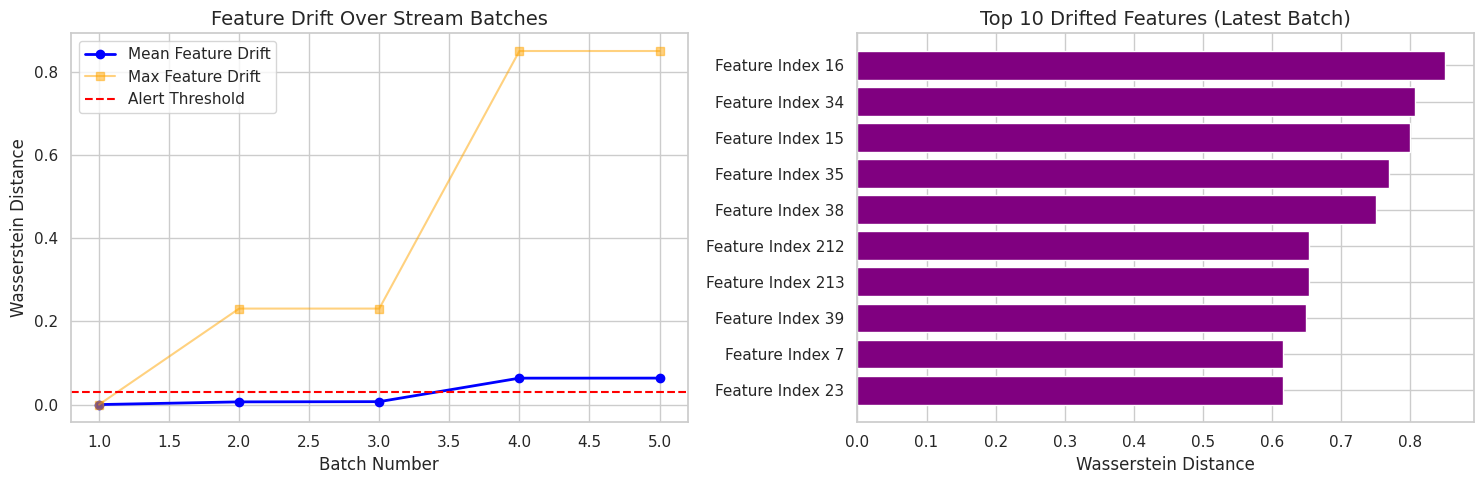

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

def compute_batch_drift(baseline_features, batch_features):
    """Computes Wasserstein distance for each feature between baseline and batch."""
    drift_scores = []
    for i in range(baseline_features.shape[1]):
        wd = wasserstein_distance(baseline_features[:, i], batch_features[:, i])
        drift_scores.append(wd)
    return np.array(drift_scores)

def simulate_and_monitor_stream(system, baseline_demos, stream_batches, threshold=0.15):
    """
    Simulates ingesting a stream of batched data, computes drift statistics,
    and renders a compact dashboard.
    """
    # 1. Extract baseline features using the system's learned feature space mappings
    _, _, s2i, _, _, _, col_min, col_max, _, _ = system._model

    def extract_features(demos):
        # Map states to indices for the feature extractor
        states = []
        for d in demos:
            states.extend([s for s, a in d[:-1]]) # exclude 'stop'
        
        # Deduplicate
        unique_states = list(set(states))
        temp_i2s = {i: s for i, s in enumerate(unique_states)}
        
        # Use the existing feature extractor to align dimensions
        fm, _, _ = create_enhanced_feature_matrix(temp_i2s, col_min_known=col_min, col_max_known=col_max)
        return fm

    print("Extracting baseline features...")
    baseline_features = extract_features(baseline_demos)
    
    history_mean_drift = []
    history_max_drift = []
    latest_drift_scores = None

    print(f"Starting stream monitoring (Alert Threshold: {threshold})...\\n")
    
    # 2. Process mock stream batches
    for batch_idx, batch_demos in enumerate(stream_batches):
        batch_features = extract_features(batch_demos)
        drift_scores = compute_batch_drift(baseline_features, batch_features)
        
        mean_drift = np.mean(drift_scores)
        max_drift = np.max(drift_scores)
        
        history_mean_drift.append(mean_drift)
        history_max_drift.append(max_drift)
        latest_drift_scores = drift_scores
        
        status = "🚨 ALERT: DRIFT DETECTED" if mean_drift > threshold else "✅ OK"
        print(f"Batch {batch_idx + 1:02d} | Mean Drift: {mean_drift:.4f} | Max Drift: {max_drift:.4f} | {status}")

    # 3. Render Compact Dashboard
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Drift over time
    batches = np.arange(1, len(stream_batches) + 1)
    ax1.plot(batches, history_mean_drift, marker='o', label='Mean Feature Drift', color='blue', linewidth=2)
    ax1.plot(batches, history_max_drift, marker='s', label='Max Feature Drift', color='orange', alpha=0.5)
    ax1.axhline(y=threshold, color='red', linestyle='--', label='Alert Threshold')
    ax1.set_title('Feature Drift Over Stream Batches', fontsize=14)
    ax1.set_xlabel('Batch Number', fontsize=12)
    ax1.set_ylabel('Wasserstein Distance', fontsize=12)
    ax1.legend()
    
    # Plot 2: Top 10 drifted features in the latest batch
    top_k = 10
    top_indices = np.argsort(latest_drift_scores)[-top_k:]
    top_scores = latest_drift_scores[top_indices]
    
    ax2.barh(np.arange(top_k), top_scores, color='purple')
    ax2.set_yticks(np.arange(top_k))
    ax2.set_yticklabels([f"Feature Index {idx}" for idx in top_indices])
    ax2.set_title(f'Top {top_k} Drifted Features (Latest Batch)', fontsize=14)
    ax2.set_xlabel('Wasserstein Distance', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# === EXECUTION SCRIPT ===
# Generate baseline data (e.g., standard recipes the model was trained on)
print("Generating baseline and mock stream data...")
baseline_demos = [system.make_demo(gen.generate_tomato_onion_soup_v1, PREF_SETS["base"]) for _ in range(5)]

# Generate a mock data stream that progressively drifts away from the baseline
stream_batch_1 = [system.make_demo(gen.generate_tomato_onion_soup_v1, PREF_SETS["base"]) for _ in range(3)] # Normal
stream_batch_2 = [system.make_demo(gen.generate_tomato_onion_soup_v1, PREF_SETS["alt"]) for _ in range(3)]  # Slight drift (pref change)
stream_batch_3 = [system.make_demo(gen.generate_tomato_onion_soup_v2, PREF_SETS["alt"]) for _ in range(3)]  # Moderate drift (recipe tweak)
stream_batch_4 = [system.make_demo(gen.generate_smoothie, PREF_SETS["base"]) for _ in range(3)]             # Severe drift (new recipe)
stream_batch_5 = [system.make_demo(gen.generate_smoothie, PREF_SETS["late_everything"]) for _ in range(3)]  # Severe drift

stream_batches = [stream_batch_1, stream_batch_2, stream_batch_3, stream_batch_4, stream_batch_5]

# Run the dashboard simulation
simulate_and_monitor_stream(system, baseline_demos, stream_batches, threshold=0.03)